---

# JOINTS x INSPIRE UGM 2026 (v17)

*Validasi blok waktu dengan purge, metadata resmi lengkap, dan pembelajaran bersama D4 sampai D10.*

---

## [Nama Tim]

- [Nama Anggota 1] (Ketua)
- [Nama Anggota 2]
- [Nama Anggota 3]

---

## Table of Contents

1. [**Introduction**](#1)
2. [**Initialization**](#2)
3. [**Data Acquisition & Audit**](#3)
4. [**Exploratory Data Analysis**](#4)
5. [**Data Cleaning**](#5)
6. [**Preprocessing**](#6)
7. [**Feature Engineering**](#7)
8. [**Modeling**](#8)
9. [**Evaluation**](#9)
10. [**Inference & Submission**](#10)


---

# Introduction <a name="1"></a>

---

## Overview

v16 menolak log1p: gain TW hanya 0,000004 dan ketiga backtest memburuk. Submisi akhirnya identik dengan v15 (public 0,39918 menurut peserta). v17 menguji dua hipotesis berbeda: informasi genre resmi yang belum digunakan dan pembelajaran lintas horizon. Tidak ada target skor yang dijanjikan; 0,33662 memerlukan penurunan error public sekitar 15,7%.

## Aim

*Memprediksi `total_ticket` D4 sampai D10 untuk 72.611 baris uji dengan MASE sekecil mungkin pada private leaderboard, memakai metrik validasi yang terbukti sejalan dengan leaderboard.*

## Metric

***Mean Absolute Scaled Error (MASE)** membagi galat absolut setiap baris dengan skala pasangan, yaitu rata-rata D1 sampai D3 yang dibatasi minimal 1. MASE setara MAE pada rasio $r = y / s_p$, sehingga prediksi optimal adalah median bersyarat. Karena MASE adalah rata-rata biasa per baris, komposisi baris uji (misalnya porsi pasangan kecil) langsung menentukan skor.*

$$s_p = \max\left(\frac{1}{3}\sum_{d=1}^{3} y_{p,d},\ 1\right) \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N}\frac{|y_i - \hat{y}_i|}{s_{p(i)}}$$

## Dataset

*Data bersumber dari Kaggle Competition Data Science JOINTS x INSPIRE UGM 2026.*

*`train.csv` berisi 138.959 transaksi harian (1 April sampai 30 September 2025). `test_history.csv` berisi 32.323 transaksi D1 sampai D3 dari 163 judul uji, dan `test.csv` berisi 72.611 baris target (10.373 pasangan x 7 hari). Hari tanpa transaksi tidak tercatat dan bernilai nol.*

*Data digunakan untuk merekonstruksi sampel latih dengan aturan panitia, lalu memprediksi D4 sampai D10.*

**Attributes**

1.  `date_show`       : Tanggal penayangan
2.  `cinema_ids`      : ID anonim klaster bioskop
3.  `city_name`       : Kota lokasi klaster
4.  `movie_title`     : Judul film, termasuk penanda format (3D, IMAX 2D, IMAX 3D)
5.  `occupation_rate` : Persentase kursi terisi (0 sampai 100)
6.  `total_show`      : Jumlah pertunjukan

**Target**
 `total_ticket`       : Jumlah tiket terjual per pasangan per tanggal (0 bila tidak ada transaksi)

## Approach

Kontrol tetap LightGBM 0,1 + TabPFN-3.5 int7 per horizon 0,9. Kandidat G menambah genre resmi lengkap pada TabPFN per horizon. Kandidat H memakai fitur baseline termasuk horizon h dalam satu TabPFN, dengan konteks maksimal 8.000 baris yang disampel seimbang menurut horizon. Keduanya diuji terpisah, tidak digabung otomatis. Target, lambda 0,5, kalender, dan analog Lebaran dibekukan.

---

# Initialization <a name="2"></a>

---

## Environment Setup

Notebook dirancang untuk Kaggle GPU T4 x2 dengan internet aktif (unduh bobot TabPFN dari Hugging Face, repo Prior Labs memerlukan secret `HF_TOKEN`). TabPFN dan TabM memakai GPU pertama; LightGBM (L1, klasifier, dan 19 regresi kuantil) berjalan di CPU dengan `deterministic=True`. Runtime v12 di T4: tangga LightGBM sekitar 20 menit, TabPFN-2.5 985 detik, TabM 193 detik, fit akhir dan inferensi 943 detik. v13 menambah lensa pasar sepi (satu fit per model) dan TabPFN-3.5 Fast, perkiraan total 2 sampai 2,5 jam.

In [1]:
!nvidia-smi

Thu Oct  8 05:41:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Seluruh dependency dipasang dengan versi spesifik untuk menjaga reproduksibilitas.

In [2]:
%pip install -q lightgbm==4.6.0 tabpfn==9.0.0 tabm==0.0.3 rtdl_num_embeddings==0.0.12 huggingface_hub==0.34.4 safetensors==0.8.0 causilo==1.0.3 scikit-learn==1.6.1 pandas==2.2.3 scipy==1.15.2 matplotlib==3.10.0 seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import Libraries

In [3]:
import os
import random
import time
import pickle
import io
import zlib
import itertools
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import torch
from IPython.display import display
from huggingface_hub import hf_hub_download
from safetensors import safe_open
from safetensors.numpy import save_file
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer
from tabm import TabM
from rtdl_num_embeddings import PiecewiseLinearEmbeddings, compute_bins
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
try:
    import causilo.checkpoints as causilo_ckpt
    from causilo import CausiloRegressor
except Exception as e:
    print('Causilo unavailable:', repr(e)[:200])
    causilo_ckpt, CausiloRegressor = None, None
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    UserSecretsClient = None

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
sns.set_theme(style='whitegrid', palette=PAL, rc={'axes.spines.top': False, 'axes.spines.right': False})

## Seed Everything

In [4]:
def seed_everything(seed: int = 2026):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(2026)

## Settings

Seluruh path, konstanta hasil EDA, hyperparameter, dan flag dipusatkan di sini. `HURDLE_W` adalah bobot hurdle dalam komponen LightGBM dan `LAMBDA` porsi pergeseran kebijakan pencopotan yang diuji per model. `REL_WIN` adalah jendela film pembanding untuk level relatif (14 hari, sama dengan analisis lokal), `QUIET_FRAC` porsi film dengan pasar paling sepi yang dijadikan lensa pasar sepi, dan `REL_GUARD` batas kenaikan grouped CV dan temporal yang diterima untuk fitur relatif. `FM_LIST` berisi kandidat TabPFN; paling banyak satu yang dipakai karena batas bobot 200 MB. `FM_STRICT = False` berarti kandidat foundation model yang gagal (misalnya kehabisan memori pada konteks penuh) dicetak jelas lalu dilewati, sedangkan LightGBM dan TabM tetap wajib. `TP35_BITS` adalah presisi kuantisasi TabPFN-3.5 penuh. Seed L1 3 (seed bagging terbukti noise di `eda/48`), agar LightGBM sekitar 20 MB dan muat bersama TabPFN-3.5 int7 dan TabM. `LEB_RHO` adalah porsi total pasar minggu Lebaran 2025 yang diasumsikan dicapai film Lebaran 2026 (Bagian 10). Tidak ada nilai yang disetel pada leaderboard.

In [5]:
class Settings:
    SEED       = 2026
    _ON_KAGGLE = Path('/kaggle/input').exists()

    DATA_DIR   = (
        next(Path('/kaggle/input').rglob('train.csv')).parent
        if _ON_KAGGLE else Path('../data')
    )
    OUTPUT_DIR = Path('/kaggle/working') if _ON_KAGGLE else Path('../outputs/v17')
    FIG_DIR    = OUTPUT_DIR / 'figures'

    TRAIN_END  = pd.Timestamp('2025-09-30')
    OUTAGE     = pd.to_datetime(['2025-06-07', '2025-06-09', '2025-06-10', '2025-06-13', '2025-06-16'])
    D1_FRAC    = 0.5
    MIN_NC     = 25
    USE_LIMITED = True

    DOW_PROF   = np.array([0.811, 0.789, 0.811, 0.783, 0.848, 1.290, 1.282])
    HOL_LEVEL  = 1.29
    SCHOOL_WD  = 1.15
    QS         = np.round(np.arange(0.05, 1.0, 0.05), 2)
    TAB_QS     = np.round(np.arange(0.02, 1.0, 0.02), 2)
    ZERO_EPS   = 0.02
    HURDLE_W   = 0.75
    LAMBDA     = 0.5
    LEB_RHO    = 0.5
    LEB_DAY1   = 0.75
    TW_BINS    = [0, 5, 20, 50, 100, 200, 500, 1e9]

    N_FOLDS    = 5
    SEEDS      = [2026, 2027, 2028]
    LGB_PARAMS = dict(objective='l1', learning_rate=0.03, num_leaves=63, min_child_samples=100,
                      feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                      n_estimators=800, deterministic=True, force_row_wise=True, n_jobs=4, verbose=-1)

    REL_WIN      = 14
    QUIET_FRAC   = 0.4
    REL_GUARD    = 0.003
    # TabPFN candidates, at most one ships: 'tabpfn25q', 'fast35'; ('tabpfn_v2',) = revision 11 Jun 2025, before the cutoff
    FM_LIST      = ('tp35_int7', 'tp35_genre', 'tp35_pool')
    POOL_CONTEXT = 8000
    FM_STRICT    = True
    FM_EST       = 8
    TP35_EST     = 16
    TP35_REPO    = 'Prior-Labs/tabpfn_3_5'                      # 876.0 MB float32, stored as int7 per row + zlib (~169 MB)
    TP35_FILE    = 'tabpfn-v3.5-20260909.safetensors'
    TP35_REV     = '06bf2ba35c80a92a3b9abb436b99cf49e7a0365e'
    TP35_SHA256  = 'ece4d67eadfea42eb0e610df5189bea60cb7f31073d81e9c7a019b76eacf0be3'
    TP35_BITS    = 7
    TP35_PACK    = 'tabpfn-v3.5-full-int7.pack'
    CAUSILO_REPO = 'nums-ai/causilo'                            # regressor 148.4 MB
    CAUSILO_REV  = '94f2bd91db0737d4da59f347910662905ecb5a09'
    CAUSILO_FILES = {'regressor/config.json': 'af78b2d23ac28534ab6c16f75d8d2d2f4dc38ca45c643d70a6324320847480a7',
                     'regressor/model.safetensors': '9a4197d7c1060d187c19b62d4d83c74ce986c1f3911825576eb58c2ae4f0057d'}
    CAUSILO_EST  = 8
    FAST_REPO    = 'Prior-Labs/tabpfn_3_5'                      # 334.2 MB float32, stored as matrix-FP16 (167.2 MB)
    FAST_FILE    = 'tabpfn-v3.5-fast-20260909.safetensors'
    FAST_REV     = '06bf2ba35c80a92a3b9abb436b99cf49e7a0365e'
    FAST_SHA256  = '14e0b81285bca7a6d1ef121169f27f651f76dff49cad6c0b8779d5c836018550'
    FAST16_FILE  = 'tabpfn-v3.5-fast-matrix-fp16.safetensors'
    SIZE_MARGIN_MB = 1.5
    TP25_REPO    = 'Prior-Labs/tabpfn_2_5'                      # 40.8 MB
    TP25_FILE    = 'tabpfn-v2.5-regressor-v2.5_quantiles.ckpt'
    TP25_REV     = '6c45f3a6d0d07c6c5f62572e04a0c2929de91b8b'
    TP25_SHA256  = '6dd4dbcdd5b991fde435ba5d59e4f6d170ec52110f5bb313ae8e972b88898044'
    USE_TABM     = False
    TABM_K       = 32
    TABM_BINS    = 48
    TABM_DEMB    = 16
    TABM_LR      = 2e-3
    TABM_WD      = 3e-4
    TABM_BATCH   = 256
    TABM_EPOCHS  = 40
    TABM_PATIENCE = 5
    TABPFN_REPO  = 'Prior-Labs/TabPFN-v2-reg'                   # 44.4 MB
    TABPFN_FILE  = 'tabpfn-v2-regressor.ckpt'
    TABPFN_REV   = '213f8e38ec399a2a385fa46cab6f22b95cd90de8'
    TABPFN_SHA256 = '2ab5a07d5c41dfe6db9aa7ae106fc6de898326c2765be66505a07e2868c10736'
    STRICT       = True
    MAX_WEIGHTS_MB = 200
    KAPPA        = 0.5
    KAPPA_SEEDS  = 3
    ABL_MIN_GAIN  = 0.0015
    ABL_MONTH_TOL = 0.003
    ABL_MIN_FOLDS = 3
    ABL_KAPPA_TOL = 0.002
    BLEND_MIN_GAIN = 0.001
    REGIONAL_CAL  = True
    DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CFG.DATA_DIR, CFG.DEVICE, '| torch', torch.__version__)
if CFG._ON_KAGGLE and CFG.DEVICE != 'cuda':
    raise RuntimeError('GPU not visible to torch (TabPFN and TabM run on the GPU)')

/kaggle/input/competitions/datajointsxinspire cuda | torch 2.14.1+cu130


## Load Dataset

Semua berkas resmi dibaca dengan kolom tanggal langsung di-parse. Tidak ada visualisasi di sini.

In [6]:
read = lambda f, **k: pd.read_csv(CFG.DATA_DIR / f, **k)
train   = read('train.csv', parse_dates=['date_show'])
hist    = read('test_history.csv', parse_dates=['date_show'])
test    = read('test.csv', parse_dates=['date_show'])
sub     = read('sample_submission.csv')
movies  = read('movies.csv')
hol     = read('holidays.csv', parse_dates=['date'])
price   = read('ticket_prices.csv')
KEY     = ['movie_title', 'cinema_ids']

for n, x in [('train', train), ('test_history', hist), ('test', test), ('movies', movies),
             ('holidays', hol), ('ticket_prices', price)]:
    print(f'{n:14s} {x.shape}')

train          (138959, 7)
test_history   (32323, 7)
test           (72611, 5)
movies         (397, 7)
holidays       (366, 4)
ticket_prices  (207, 3)


---

# Data Acquisition & Audit <a name="3"></a>

---

Integritas data diperiksa sebelum analisis: rentang tanggal, nilai hilang, duplikat kunci, konsistensi klaster ke kota, dan irisan film serta klaster antara data latih dan data uji.

In [7]:
rows = []
for n, x in [('train', train), ('test_history', hist), ('test', test)]:
    rows.append(dict(file=n, rows=len(x), start=x.date_show.min().date(), end=x.date_show.max().date(),
                     films=x.movie_title.nunique(), cinemas=x.cinema_ids.nunique(), n_missing=int(x.isna().sum().sum())))
display(pd.DataFrame(rows))
for n, x in [('train', train), ('test_history', hist)]:
    print(f"{n}: duplicate (date, cinema, film) = {x.duplicated(['date_show'] + KEY).sum()}, zero-ticket rows = {(x.total_ticket == 0).sum()}")
print('clusters mapped to >1 city:', (pd.concat([train, hist]).groupby('cinema_ids').city_name.nunique() > 1).sum())
print('test ids aligned with sample_submission:', (sub.id.values == test.id.values).all())
print('test films also in train (previews):', len(set(test.movie_title) & set(train.movie_title)))
print('test clusters unseen in train:', len(set(test.cinema_ids) - set(train.cinema_ids)))

,file,rows,start,end,films,cinemas,n_missing
0,train,138959,2025-04-01,2025-09-30,237,117,0
1,test_history,32323,2025-10-01,2026-03-20,163,121,0
2,test,72611,2025-10-04,2026-03-27,160,121,0


train: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
test_history: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
clusters mapped to >1 city: 0
test ids aligned with sample_submission: True
test films also in train (previews): 10
test clusters unseen in train: 4


#### Insights

> Tidak ada nilai hilang, duplikat kunci, maupun baris bertiket nol: hari tanpa transaksi memang tidak tercatat, sehingga target harus diisi nol secara eksplisit. Sepuluh film uji muncul di train hanya sebagai pratinjau di beberapa klaster, dan empat klaster uji tidak pernah muncul di train.

---

# Exploratory Data Analysis <a name="4"></a>

---

EDA menjawab tiga pertanyaan yang langsung mengubah pipeline: bagaimana panitia membentuk data uji, periode kalender apa yang tidak pernah dilihat data latih, dan apakah level pasar periode uji berbeda.

## Aturan Seleksi Pasangan dan Filter Rilis Luas

`test_history.csv` memuat 11.823 pasangan, tetapi `test.csv` hanya 10.373. Pasangan dikelompokkan menurut hari terakhir yang masih bertransaksi, lalu cakupan klaster D1 film uji dibandingkan dengan judul di `movies.csv` yang tidak dipakai.

In [8]:
base_title = lambda t: t.str.replace(r'\s*\((IMAX 2D|IMAX 3D|3D)\)\s*$', '', regex=True).str.strip()
fmt = lambda t: t.str.extract(r'\((IMAX 2D|IMAX 3D|3D)\)\s*$')[0].fillna('2D')

d1_test = hist.groupby('movie_title').date_show.min()
h = hist.join(d1_test.rename('d1'), on='movie_title')
h['d'] = (h.date_show - h.d1).dt.days + 1
ph = h.groupby(KEY).d.max().rename('last_day').reset_index()
ph = ph.merge(test[KEY].drop_duplicates().assign(in_test=1), how='left').fillna({'in_test': 0})
display(pd.crosstab(ph.last_day, ph.in_test, margins=True))
nc1 = h[h.d == 1].groupby('movie_title').cinema_ids.nunique()
print('smallest D1 coverage of 2D test films:', nc1[fmt(pd.Series(nc1.index, index=nc1.index)) == '2D'].nsmallest(4).to_dict())
known = set(base_title(pd.Series(train.movie_title.unique()))) | set(base_title(pd.Series(hist.movie_title.unique())))
print('titles in movies.csv used nowhere:', len(set(movies.original_title) - known))
print('D1 weekday of test films:', d1_test.dt.day_name().value_counts().to_dict())

in_test,0.0,1.0,All
last_day,,,
1,514,0,514
2,936,0,936
3,0,10373,10373
All,1450,10373,11823


smallest D1 coverage of 2D test films: {'EPIC: ELVIS PRESLEY IN CONCERT': 28, '5 CENTIMETERS PER SECOND (ANIMATION)': 30, 'ONCE WE WERE US': 30, 'SETANNYA CUAN': 33}
titles in movies.csv used nowhere: 56
D1 weekday of test films: {'Wednesday': 67, 'Thursday': 65, 'Friday': 24, 'Saturday': 5, 'Tuesday': 2}


#### Insights

> Pasangan masuk data uji **jika dan hanya jika** bertransaksi pada D3. Film 2D terkecil di data uji dibuka di 28 klaster, sedangkan 56 judul lain (Bollywood rilis terbatas, konser, nobar) tidak dipakai: data uji hanya berisi rilis luas. D1 hampir selalu Rabu atau Kamis, yaitu tanggal rilis resmi.

## Efek Kalender dan Periode yang Tidak Ada di Data Latih

Efek kalender diisolasi dengan membagi penjualan setiap pasangan-hari dengan rata-rata bergerak 7 hari terpusat milik pasangan itu sendiri, sehingga umur film dan ukuran klaster terhapus.

weekday multiplier: {'Mon': 0.814, 'Tue': 0.794, 'Wed': 0.811, 'Thu': 0.783, 'Fri': 0.853, 'Sat': 1.32, 'Sun': 1.282}


,name,dow,excess
date_show,,,
2025-04-18,Wafat Yesus Kristus,4,1.54
2025-04-20,Kebangkitan Yesus Kristus (Paskah),6,0.88
2025-05-01,Hari Buruh Internasional,3,1.85
2025-05-12,Hari Raya Waisak 2569 BE,0,1.88
2025-05-29,Kenaikan Yesus Kristus,3,1.98
2025-06-01,Hari Lahir Pancasila,6,0.35
2025-06-06,Idul Adha 1446 H,4,3.08
2025-06-27,1 Muharam Tahun Baru Islam 1447 H,4,1.48
2025-08-17,Proklamasi Kemerdekaan Republik Indonesia,6,1.11


xmas     test rows   5235 (7.2%), films 15
ramadan  test rows  12408 (17.1%), films 37
lebaran  test rows   4417 (6.1%), films 7


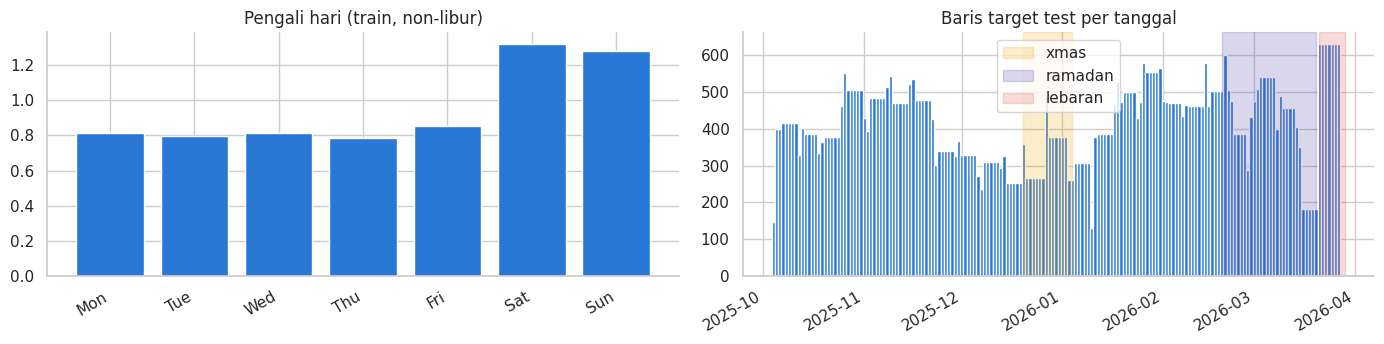

In [9]:
DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = train.set_index('date_show').groupby(KEY).total_ticket.apply(lambda s: s.asfreq('D', fill_value=0)).reset_index()
x['m7'] = x.groupby(KEY).total_ticket.transform(lambda s: s.rolling(7, center=True).mean())
x = x[(x.m7 >= 20) & ~x.date_show.isin(CFG.OUTAGE)].merge(hol, left_on='date_show', right_on='date', how='left')
x['mult'] = x.total_ticket / x.m7
day = x.groupby('date_show').agg(mult=('mult', 'median'), hol=('holiday_tipe', 'first'), name=('holiday_name', 'first'))
day['dow'] = day.index.dayofweek
prof = day[day.hol == 'normal'].groupby('dow').mult.median()
day['excess'] = day.mult / day.dow.map(prof)
print('weekday multiplier:', dict(zip(DOW, prof.round(3))))
display(day[day.hol == 'holiday'][['name', 'dow', 'excess']].round(2))

SEGMENTS = {'xmas': ('2025-12-20', '2026-01-04'), 'ramadan': ('2026-02-19', '2026-03-20'), 'lebaran': ('2026-03-21', '2026-03-29')}
for n, (a, b) in SEGMENTS.items():
    m = test.date_show.between(a, b)
    print(f'{n:8s} test rows {m.sum():6d} ({m.mean():.1%}), films {test[m].movie_title.nunique()}')

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].bar(DOW, prof.values, color=PAL[0]); ax[0].set(title='Pengali hari (train, non-libur)')
cnt = test.groupby('date_show').size()
ax[1].bar(cnt.index, cnt.values, width=1, color=PAL[0])
for (n, (a, b)), c in zip(SEGMENTS.items(), [PAL[3], PAL[6], PAL[7]]):
    ax[1].axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.2, label=n)
ax[1].set(title='Baris target test per tanggal'); ax[1].legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'calendar.png'); plt.show()

#### Insights

> Sabtu dan Minggu sekitar 1,6 kali hari kerja, libur di hari kerja setara akhir pekan, libur di akhir pekan hampir tidak menambah. Sekitar 30% baris uji berada di periode yang tidak pernah ada di train: Ramadan (17,1%), libur Natal dan Tahun Baru (7,2%), dan Lebaran (6,1%). Efek kalender karena itu dimasukkan secara struktural sebagai pengali target, bukan dipelajari pohon keputusan yang tidak bisa ekstrapolasi.

## Level Pasar dan Ukuran Pasangan

Okupansi median per bulan dan distribusi skala pasangan D1 sampai D3 dibandingkan antara train dan data uji. Skala dihitung dengan rumus resmi pada seluruh pasangan yang laku di D3.

test pairs by scale bucket: {Interval(0.0, 5.0, closed='right'): 0.015, Interval(5.0, 20.0, closed='right'): 0.114, Interval(20.0, 50.0, closed='right'): 0.198, Interval(50.0, 100.0, closed='right'): 0.2, Interval(100.0, 200.0, closed='right'): 0.195, Interval(200.0, 500.0, closed='right'): 0.178, Interval(500.0, 1000000000.0, closed='right'): 0.1}


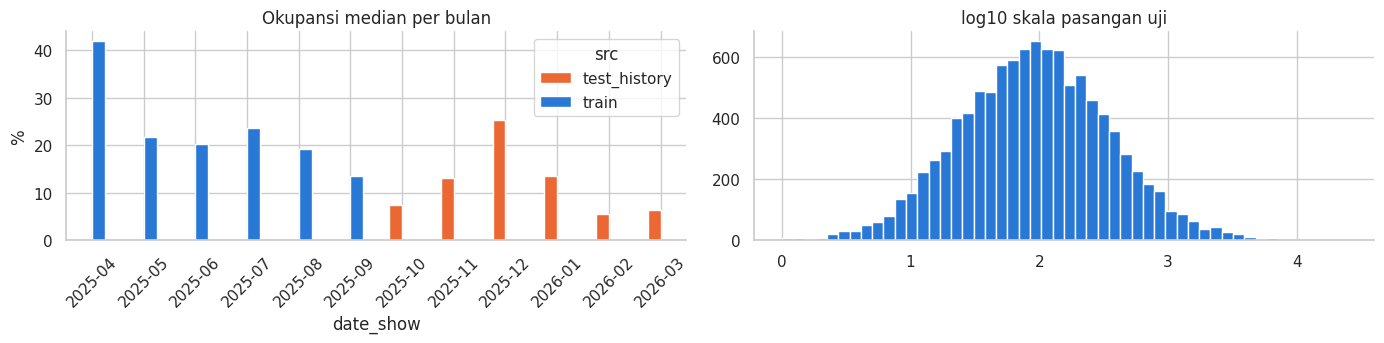

In [10]:
occ = pd.concat([train.assign(src='train'), hist.assign(src='test_history')])
occ_m = occ.groupby([occ.date_show.dt.to_period('M'), 'src']).occupation_rate.median().unstack()
s_te = (hist.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).reindex(pd.MultiIndex.from_frame(test[KEY].drop_duplicates()))
bins = CFG.TW_BINS
print('test pairs by scale bucket:', pd.cut(s_te, bins).value_counts(normalize=True).sort_index().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
occ_m.plot.bar(ax=ax[0], rot=45, color=[PAL[1], PAL[0]]); ax[0].set(title='Okupansi median per bulan', ylabel='%')
ax[1].hist(np.log10(s_te), bins=50, color=PAL[0]); ax[1].set(title='log10 skala pasangan uji')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'market.png'); plt.show()

#### Insights

> Okupansi median Oktober 2025 (7,6%), Februari (5,5%), dan Maret 2026 (6,4%) berada di bawah semua bulan train (13,6% sampai 41,8%). Pasar periode uji jauh lebih sepi, sehingga pasangan uji jauh lebih kecil: 13% baris uji memiliki skala di bawah 20. Konsekuensinya diukur di Bagian 6 dan Bagian 8.

---

# Data Cleaning <a name="5"></a>

---

Target dibentuk dengan zero-fill, sehingga hari ketika sistem pelaporan mati akan menjadi nol palsu. Selain itu, akhir pekan pratinjau berbayar sebelum rilis resmi dapat terbaca sebagai D1.

dates with no data: [datetime.date(2025, 6, 13)]
dates with < 70% of clusters reporting: {Timestamp('2025-06-07 00:00:00'): 10.0, Timestamp('2025-06-09 00:00:00'): 1.0, Timestamp('2025-06-10 00:00:00'): 67.0, Timestamp('2025-06-11 00:00:00'): 76.0, Timestamp('2025-06-16 00:00:00'): 62.0}
A MINECRAFT MOVIE coverage 1-10 Apr: {Timestamp('2025-04-04 00:00:00'): 55, Timestamp('2025-04-05 00:00:00'): 68, Timestamp('2025-04-06 00:00:00'): 67, Timestamp('2025-04-09 00:00:00'): 93, Timestamp('2025-04-10 00:00:00'): 91}


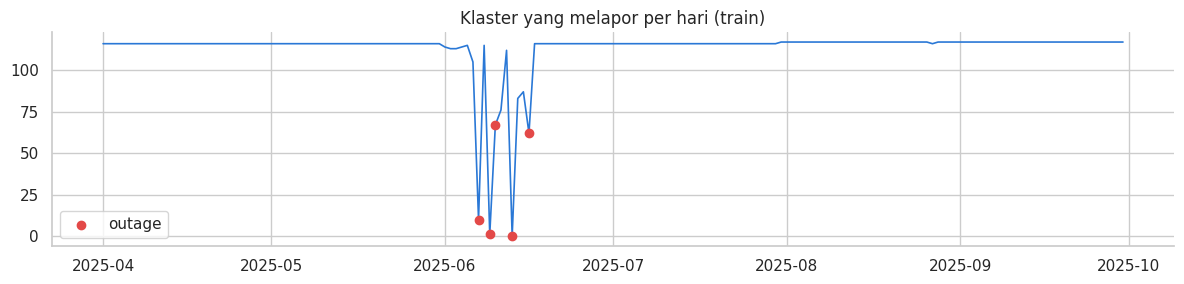

In [11]:
rep = train.groupby('date_show').cinema_ids.nunique().reindex(pd.date_range('2025-04-01', CFG.TRAIN_END))
print('dates with no data:', rep[rep.isna()].index.date.tolist())
print('dates with < 70% of clusters reporting:', rep[rep < 0.7 * rep.median()].to_dict())
mc = train[train.movie_title == 'A MINECRAFT MOVIE'].groupby('date_show').cinema_ids.nunique()
print('A MINECRAFT MOVIE coverage 1-10 Apr:', mc.loc[:'2025-04-10'].to_dict())
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rep.index, rep.fillna(0), lw=1.2)
ax.scatter(CFG.OUTAGE, rep.reindex(CFG.OUTAGE).fillna(0), color=PAL[7], zorder=3, label='outage')
ax.set(title='Klaster yang melapor per hari (train)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'outage.png'); plt.show()

#### Insights

> Lima tanggal Juni 2025 adalah outage pelaporan (13 Juni kosong, 9 Juni hanya 1 klaster). Baris target pada tanggal tersebut dibuang dan film yang D1 sampai D3-nya menyentuh outage tidak dijadikan sampel. A MINECRAFT MOVIE memiliki pratinjau 4 sampai 6 April lalu jeda sebelum rilis resmi 9 April: D1 dicari hanya di dalam segmen tayang kontinu yang memuat puncak cakupan.

---

# Preprocessing <a name="6"></a>

---

`train.csv` tidak memiliki penanda D1 sampai D10. Aturan panitia direplikasi: D1 rilis resmi, rilis luas, pasangan laku di D3, target nol diisi eksplisit. Hasilnya diverifikasi terhadap data uji, termasuk dengan tugas proxy yang memiliki label di dalam periode uji.

## Rekonstruksi D1 dan Simulasi Sampel

D1 adalah hari pertama cakupan klaster judul dasar mencapai 50% puncak, dicari di dalam segmen tayang kontinu yang memuat puncak. Judul dengan cakupan D1 di bawah 25 klaster dipisahkan sebagai film rilis terbatas: tidak pernah dievaluasi, tetapi dipakai sebagai data latih tambahan untuk pasangan kecil.

In [12]:
def release_dates(tx, frac=CFG.D1_FRAC, min_nc=CFG.MIN_NC):
    x = tx.assign(base=base_title(tx.movie_title))
    nc = x.groupby(['base', 'date_show']).cinema_ids.nunique()
    out = {}
    for b, s in nc.groupby(level=0):
        s = s.droplevel(0)
        s = s.reindex(pd.date_range(s.index.min(), s.index.max()), fill_value=0)
        pk = s.idxmax()
        z = s[:pk][s[:pk] == 0]
        seg = s[z.index.max() + pd.Timedelta(days=1):] if len(z) else s
        c = seg[seg >= frac * s.max()]
        if len(c) and c.iloc[0] >= min_nc:
            out[b] = c.index[0]
    t = x.drop_duplicates('movie_title').set_index('movie_title').base
    return t.map(pd.Series(out, dtype='datetime64[ns]')).dropna().rename('d1')


def simulate(tx, d1, last_date=CFG.TRAIN_END, bad=CFG.OUTAGE):
    d1 = d1[d1 + pd.Timedelta(days=9) <= last_date]
    if len(bad):
        d1 = d1[~np.any([(d1 <= b) & (d1 + pd.Timedelta(days=2) >= b) for b in bad], axis=0)]
    x = tx.merge(d1, left_on='movie_title', right_index=True)
    x['d'] = (x.date_show - x.d1).dt.days + 1
    hs = x[x.d.between(1, 3)].drop(columns=['d1', 'd']).reset_index(drop=True)
    pairs = x.loc[x.d == 3, KEY].drop_duplicates().merge(d1, left_on='movie_title', right_index=True)
    tg = pairs.loc[pairs.index.repeat(7)].copy()
    tg['date_show'] = tg.d1 + pd.to_timedelta(np.tile(np.arange(3, 10), len(pairs)), unit='D')
    y = x[x.d.between(4, 10)][KEY + ['date_show', 'total_ticket']]
    tg = tg.merge(y, on=KEY + ['date_show'], how='left').fillna({'total_ticket': 0})
    tg = tg[~tg.date_show.isin(bad)]
    tg['city_name'] = tg.cinema_ids.map(tx.drop_duplicates('cinema_ids').set_index('cinema_ids').city_name)
    return hs, tg.drop(columns='d1').reset_index(drop=True)


def pair_scale(h):
    return (h.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).rename('scale')


def mase(y, p, s):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p)) / np.asarray(s)))


first = train.groupby('movie_title').date_show.min()
running = first[first == first.min()].index
D_wide = release_dates(train)
D_lim = release_dates(train, CFG.D1_FRAC, 0).drop(D_wide.index, errors='ignore').drop(running, errors='ignore')
hs, ts = simulate(train, D_wide.drop(running, errors='ignore'))
hl, tl = simulate(train, D_lim)
print(f'wide releases: {ts.movie_title.nunique()} films, {len(ts)} target rows | limited (train only): {tl.movie_title.nunique()} films, {len(tl)} rows')
print('A MINECRAFT MOVIE D1:', D_wide['A MINECRAFT MOVIE'].date())

wide releases: 143 films, 56372 target rows | limited (train only): 36 films, 1435 rows
A MINECRAFT MOVIE D1: 2025-04-09


Fungsi `simulate` diuji pada film sintetis: klaster B tidak laku di D3 sehingga harus dibuang, dan hari tanpa transaksi harus menjadi nol.

In [13]:
dd = pd.date_range('2025-05-01', periods=12)
toy = pd.DataFrame({'date_show': list(dd) + [dd[0], dd[1]], 'cinema_ids': ['A'] * 12 + ['B', 'B'], 'city_name': 'X',
                    'movie_title': 'M', 'total_ticket': list(range(1, 13)) + [5, 5], 'occupation_rate': 1.0,
                    'total_show': 1}).drop(index=5)
th_, tg_ = simulate(toy, pd.Series({'M': dd[0]}, name='d1'), bad=pd.DatetimeIndex([]))
assert set(tg_.cinema_ids) == {'A'} and tg_.total_ticket.tolist() == [4, 5, 0, 7, 8, 9, 10]
assert np.isclose(pair_scale(th_)[('M', 'B')], 10 / 3)
print('simulate() self-check passed')

simulate() self-check passed


#### Insights

> Aturan D1 memakai puncak cakupan sepanjang riwayat film, yaitu informasi masa depan. Audit lokal (`eda/53`) membandingkannya dengan aturan yang benar-benar kausal: D1 = hari pertama yang jendela D1 sampai D3-nya sendiri memiliki minimal 25 klaster setiap hari, tanpa melihat puncak. Aturan itu memindahkan 6 film (A MINECRAFT MOVIE ke pratayang berbayar 4 April, BELIEVE 20 hari lebih awal), mengubah skala 191 pasangan bersama (varian yang masih memakai segmen puncak: 125), dan membuang 15 film yang dibuka di minimal 25 klaster lalu runtuh di D2 sampai D3 (rasio cakupan D3/D1 median 0,34, misalnya ARTI CINTA 52 menjadi 2 klaster). Jarak KS rasio cakupan ke data uji memang turun (0,196 menjadi 0,106), tetapi hanya karena ekor bawah itu dibuang.

> Data uji justru memuat pembukaan yang runtuh seperti itu: 8 film uji punya hari dengan kurang dari 25 klaster (SEND HELP 52, 49, lalu 1 klaster; G-DRAGON IN CINEMA 55, 30, 3) dan 30 film uji memiliki rasio cakupan D3/D1 di bawah 0,8. Seleksi panitia karena itu konsisten dengan aturan cakupan D1 (aturan sekarang), bukan dengan syarat jendela lebar tiga hari. Aturan D1 dipertahankan dengan dasar ini, bukan karena perubahannya kecil.

## Verifikasi: Komposisi dan Periode Uji

Sampel simulasi dibandingkan dengan data uji. Karena target uji tidak tersedia, dibuat tugas proxy yang memiliki label di **dalam periode uji**: memprediksi D3 dari D1 dan D2. Model proxy dilatih pada train, lalu galatnya per bucket skala dibandingkan antara validasi silang train dan periode uji.

,train_share,test_share,train_cv_mase,test_period_mase,train_zero_D3,test_zero_D3
s,,,,,,
"(0.0, 5.0]",0.004,0.024,1.062,1.171,0.771,0.544
"(5.0, 20.0]",0.053,0.134,0.750,0.693,0.568,0.308
"(20.0, 50.0]",0.134,0.208,0.612,0.587,0.392,0.107
"(50.0, 100.0]",0.173,0.195,0.533,0.481,0.129,0.028
"(100.0, 200.0]",0.217,0.185,0.418,0.410,0.031,0.011
"(200.0, 500.0]",0.249,0.160,0.342,0.344,0.004,0.002
"(500.0, 1000000000.0]",0.170,0.093,0.355,0.285,0.002,0.000


proxy MASE: train CV 0.4544 | re-weighted to test scale mix 0.5232 | real test period 0.4950


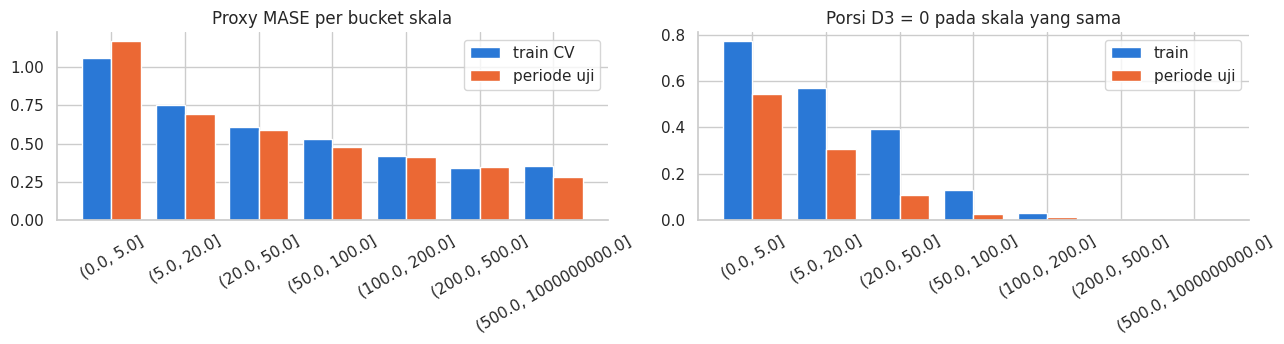

In [14]:
def proxy(hh):
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    x = hh.join(d1, on='movie_title')
    x['d'] = (x.date_show - x.d1).dt.days + 1
    P = x.pivot_table(index=KEY, columns='d', values='total_ticket', fill_value=0).reindex(columns=[1, 2, 3], fill_value=0)
    S = x.pivot_table(index=KEY, columns='d', values='total_show', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    O = x.pivot_table(index=KEY, columns='d', values='occupation_rate', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    P = P[P[2] > 0]
    f = pd.DataFrame({'s': ((P[1] + P[2]) / 2).clip(lower=1), 'y': P[3]}, index=P.index)
    f['q1'], f['q2'], f['log_s'] = P[1] / f.s, P[2] / f.s, np.log1p(f.s)
    f['sh1'], f['sh2'] = S.reindex(P.index)[1], S.reindex(P.index)[2]
    f['sh_tr'] = (f.sh2 + 1) / (f.sh1 + 1)
    f['occ2'] = O.reindex(P.index)[2]
    f = f.reset_index().join(d1, on='movie_title')
    g = x[x.d <= 2].groupby(['movie_title', 'd']).total_ticket.sum().unstack().reindex(columns=[1, 2], fill_value=0)
    f['f_tr'] = f.movie_title.map((g[2] + 1) / (g[1] + 1))
    f['f_log'] = f.movie_title.map(np.log1p(g.mean(axis=1)))
    f['f_nc'] = f.movie_title.map(x[x.d == 2].groupby('movie_title').cinema_ids.nunique())
    f['d1_dow'] = f.d1.dt.dayofweek
    return f


PA, PB = proxy(hs), proxy(hist)
pc = ['q1', 'q2', 'log_s', 'sh_tr', 'f_tr', 'f_log', 'd1_dow']
pm = dict(objective='l1', n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=100, verbose=-1, deterministic=True, force_row_wise=True)
oofA = np.zeros(len(PA))
for a, b in GroupKFold(5).split(PA, groups=base_title(PA.movie_title)):
    m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA.iloc[a][pc], PA.y.iloc[a] / PA.s.iloc[a])
    oofA[b] = np.clip(m.predict(PA.iloc[b][pc]), 0, None) * PA.s.values[b]
m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA[pc], PA.y / PA.s)
pB = np.clip(m.predict(PB[pc]), 0, None) * PB.s.values
eA, eB = np.abs(PA.y - oofA) / PA.s, np.abs(PB.y - pB) / PB.s
cutA, cutB = pd.cut(PA.s, bins), pd.cut(PB.s, bins)
tab = pd.DataFrame({'train_share': cutA.value_counts(normalize=True), 'test_share': cutB.value_counts(normalize=True),
                    'train_cv_mase': eA.groupby(cutA, observed=False).mean(), 'test_period_mase': eB.groupby(cutB, observed=False).mean(),
                    'train_zero_D3': (PA.y == 0).groupby(cutA, observed=False).mean(), 'test_zero_D3': (PB.y == 0).groupby(cutB, observed=False).mean()}).sort_index()
display(tab.round(3))
print(f'proxy MASE: train CV {eA.mean():.4f} | re-weighted to test scale mix {(tab.test_share * tab.train_cv_mase).sum():.4f} | real test period {eB.mean():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tab))
ax[0].bar(xx - .2, tab.train_cv_mase, .4, label='train CV'); ax[0].bar(xx + .2, tab.test_period_mase, .4, label='periode uji')
ax[0].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[0].set(title='Proxy MASE per bucket skala'); ax[0].legend()
ax[1].bar(xx - .2, tab.train_zero_D3, .4, label='train'); ax[1].bar(xx + .2, tab.test_zero_D3, .4, label='periode uji')
ax[1].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[1].set(title='Porsi D3 = 0 pada skala yang sama'); ax[1].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'proxy.png'); plt.show()

#### Insights

> Galat per bucket skala hampir sama antara validasi silang train dan periode uji, tetapi data uji memuat jauh lebih banyak pasangan kecil yang galatnya terbesar. Karena itu metrik keputusan adalah **TW-MASE**. TW-MASE v2 (0,377) dan v3 (0,388) memberi peringkat yang sama dengan leaderboard (0,4506 dan 0,4573), tetapi keduanya berjarak tetap sekitar 0,07.

> Pada skala absolut yang sama, porsi pasangan yang berhenti di D3 jauh lebih kecil di periode uji (skala 20 sampai 50: 0,39 di train vs 0,11 di uji). Bagian berikut menguji apakah ini efek musim atau perubahan perilaku bioskop.

## Kebijakan Pencopotan di Periode Uji

Porsi pasangan yang berhenti laku di D3 dibandingkan pada **permintaan per pertunjukan yang sama** (tiket per show D1 sampai D2), sehingga perbedaan ukuran pasar tidak ikut terhitung. Besarnya pergeseran diestimasi di Bagian 8 setelah kalender tersedia.

,train_drop_D3,test_drop_D3,train_n,test_n
"(0.226, 7.8]",0.499,0.219,948,3070
"(7.8, 14.833]",0.256,0.063,1393,2605
"(14.833, 25.2]",0.085,0.030,1795,2221
"(25.2, 44.9]",0.023,0.014,2296,1702
"(44.9, 425.167]",0.002,0.005,2531,1476


D3 stop rate by release month: {Period('2025-04', 'M'): 0.082, Period('2025-05', 'M'): 0.13, Period('2025-06', 'M'): 0.173, Period('2025-07', 'M'): 0.083, Period('2025-08', 'M'): 0.137, Period('2025-09', 'M'): 0.096, Period('2025-10', 'M'): 0.096, Period('2025-11', 'M'): 0.08, Period('2025-12', 'M'): 0.062, Period('2026-01', 'M'): 0.081, Period('2026-02', 'M'): 0.107, Period('2026-03', 'M'): 0.066}


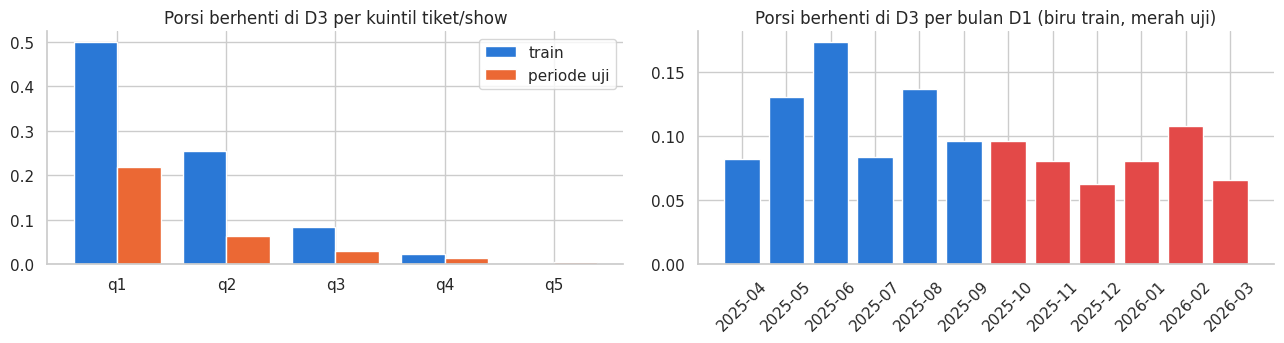

In [15]:
DA = PA.assign(z=PA.y == 0, tps=PA.s * 2 / (PA.sh1 + PA.sh2).clip(lower=1))
DB = PB.assign(z=PB.y == 0, tps=PB.s * 2 / (PB.sh1 + PB.sh2).clip(lower=1))
q = pd.qcut(pd.concat([DA.tps, DB.tps]), 5)
qa, qb = q.iloc[:len(DA)].values, q.iloc[len(DA):].values
tq = pd.DataFrame({'train_drop_D3': DA.z.groupby(qa, observed=False).mean(), 'test_drop_D3': DB.z.groupby(qb, observed=False).mean(),
                   'train_n': pd.Series(qa).value_counts(), 'test_n': pd.Series(qb).value_counts()})
display(tq.round(3))
zm = pd.concat([DA.assign(m=DA.d1.dt.to_period('M')), DB.assign(m=DB.d1.dt.to_period('M'))]).groupby('m').z.mean()
print('D3 stop rate by release month:', zm.round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tq))
ax[0].bar(xx - .2, tq.train_drop_D3, .4, label='train'); ax[0].bar(xx + .2, tq.test_drop_D3, .4, label='periode uji')
ax[0].set_xticks(xx, [f'q{i + 1}' for i in xx]); ax[0].set(title='Porsi berhenti di D3 per kuintil tiket/show'); ax[0].legend()
ax[1].bar(zm.index.astype(str), zm.values, color=[PAL[0] if str(m) < '2025-10' else PAL[7] for m in zm.index])
ax[1].set(title='Porsi berhenti di D3 per bulan D1 (biru train, merah uji)'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'pull_policy.png'); plt.show()

#### Insights

> Pada tiket per show absolut yang sama, porsi pasangan yang berhenti di D3 di periode uji hanya sekitar setengah sampai seperempat porsi train. Sejak v4 ini dibaca sebagai perubahan kebijakan bioskop dan dikoreksi dengan $\lambda a$. Tetapi porsi berhenti per bulan tetap 5 sampai 17% di kedua periode walaupun okupansi periode uji turun ke separuhnya (Februari 2026: okupansi median 5%, porsi berhenti tetap sekitar 10%). Ambang absolut yang konstan tidak menghasilkan pola itu; bagian berikut menguji penjelasan lain.

> Di train, kecenderungan klaster mencopot di D3 juga hampir tidak terbawa ke nol D4 sampai D10: klaster yang 1 logit lebih "lengket" di D3 hanya 0,09 logit lebih lengket di D4 sampai D10 setelah koreksi reliabilitas (`eda/67`, 116 klaster). Jadi besar pergeseran di D3 tidak bisa dipindahkan begitu saja ke horizon target.

## Tolok Ukur Relatif: Pergeseran Kebijakan atau Pasar yang Sepi?

Bila bioskop memutuskan mencopot film berdasarkan kinerjanya **dibanding film lain di bioskop yang sama**, maka di pasar yang sepi semua film terlihat kecil secara absolut, tetapi yang dicopot tetap yang paling lemah secara relatif. Tiket per show setiap pasangan dibagi median tiket per show film lain di klaster yang sama yang D1-nya berjarak paling jauh 14 hari. Referensi hanya memakai jendela D1 sampai D3 film lain (train dan `test_history`), informasi yang sama di kedua periode. Tabel lookup desil dibangun dari train, lalu offset logit periode uji dihitung untuk kedua tolok ukur.

,test_pairs,expected_test,observed_test,logit_offset
absolute tickets/show,11074.0,0.220,0.085,-1.31
tickets/show vs other films in cluster,11066.0,0.115,0.085,-0.44


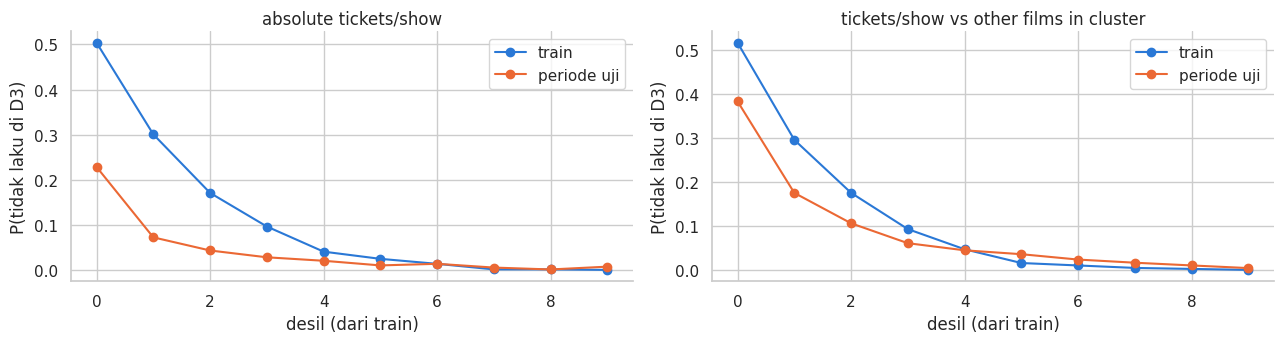

In [16]:
def visible_windows(tx, d1):
    x = tx.merge(d1.rename('d1'), left_on='movie_title', right_index=True)
    return x[(x.date_show >= x.d1) & (x.date_show <= x.d1 + pd.Timedelta(days=2))].drop(columns='d1')


vis_tr = visible_windows(train, D_wide)
VIS = pd.concat([vis_tr, hist], ignore_index=True)
VIS['base'] = base_title(VIS.movie_title)
VIS_D1 = VIS.groupby('base').date_show.min().rename('d1')
VP = VIS.groupby(['base', 'cinema_ids']).agg(tix=('total_ticket', 'sum'), shows=('total_show', 'sum')).reset_index().join(VIS_D1, on='base')
VP['sc'], VP['tps'] = VP.tix / 3, VP.tix / VP.shows.clip(lower=1)
VF = (VIS.groupby('base').total_ticket.sum() / 3).rename('ft').to_frame().join(VIS_D1).reset_index()


def ref_cluster(Q, col, win=CFG.REL_WIN, min_n=2):
    q = Q[['movie_title', 'cinema_ids', 'd1']].drop_duplicates()
    q = q.assign(base=base_title(q.movie_title))
    m = q.merge(VP[['base', 'cinema_ids', 'd1', col]].rename(columns={'base': 'base_o', 'd1': 'd1_o'}), on='cinema_ids')
    m = m[((m.d1 - m.d1_o).dt.days.abs() <= win) & (m.base != m.base_o)]
    g = m.groupby(['movie_title', 'cinema_ids'])[col].agg(['median', 'size'])
    med = g['median'].where(g['size'] >= min_n)
    return pd.MultiIndex.from_frame(Q[['movie_title', 'cinema_ids']]).map(med).values.astype(float)


def ref_national(Q, pool, col, win=CFG.REL_WIN):
    fd = Q.drop_duplicates('movie_title').set_index('movie_title').d1
    fb = base_title(pd.Series(fd.index, index=fd.index))
    days = pool.d1.values.astype('datetime64[D]').astype(np.int64)
    out = {}
    for m_, t_ in fd.items():
        k = (np.abs(days - np.datetime64(t_, 'D').astype(np.int64)) <= win) & (pool.base.values != fb[m_])
        out[m_] = np.median(pool[col].values[k])
    return Q.movie_title.map(out).values.astype(float)


logit = lambda p: np.log(p / (1 - p))
sigm = lambda t: 1 / (1 + np.exp(-t))
nll = lambda p, z, a: -np.mean(z * np.log(sigm(logit(p) + a)) + (1 - z) * np.log(1 - sigm(logit(p) + a)))
grid_a = np.linspace(-4, 2, 601)
for D_ in (DA, DB):
    D_['tps_clu'] = D_.tps / ref_cluster(D_, 'tps')


def stop_lookup(col):
    a_, b_ = DA.dropna(subset=[col]), DB.dropna(subset=[col])
    e = np.unique(np.quantile(np.log(a_[col].clip(lower=1e-3)), np.linspace(0, 1, 11)))
    bin_ = lambda D_: np.clip(np.searchsorted(e, np.log(D_[col].clip(lower=1e-3)), side='right') - 1, 0, len(e) - 2)
    look = a_.z.groupby(bin_(a_)).mean()
    pe = np.clip(pd.Series(bin_(b_)).map(look).values, 1e-3, 1 - 1e-3)
    zb = b_.z.values.astype(float)
    off = float(grid_a[np.argmin([nll(pe, zb, a) for a in grid_a])])
    curves = pd.DataFrame({'train': look, 'test': b_.z.groupby(bin_(b_)).mean()})
    return dict(test_pairs=len(b_), expected_test=pe.mean(), observed_test=zb.mean(), logit_offset=off), curves


YARD = {'absolute tickets/show': 'tps', 'tickets/show vs other films in cluster': 'tps_clu'}
yard = {k: stop_lookup(c) for k, c in YARD.items()}
display(pd.DataFrame({k: v[0] for k, v in yard.items()}).T.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a_, (k, (_, cv)) in zip(ax, yard.items()):
    a_.plot(cv.index, cv.train, marker='o', label='train'); a_.plot(cv.index, cv.test, marker='o', label='periode uji')
    a_.set(title=k, xlabel='desil (dari train)', ylabel='P(tidak laku di D3)'); a_.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'stop_yardstick.png'); plt.show()

#### Insights

> Dengan tolok ukur absolut, peluang berhenti di D3 pada desil terbawah sekitar 0,50 di train tetapi 0,22 di periode uji (offset logit sekitar -1,3). Dengan tolok ukur relatif terhadap film lain di klaster yang sama, kurva periode uji mendekati kurva train dan offset menyusut ke sekitar -0,4 di sel ini (referensi D1 sampai D3 semua film yang terlihat) atau -0,2 di analisis lokal `eda/68` (referensi D1 sampai D2 pasangan proxy), dengan daya pisah di train yang sama (log-loss 0,227 vs 0,230). Sisa selisih ada di dua desil terbawah (sekitar 0,38 vs 0,52), jadi tidak seluruh pergeseran adalah artefak, tetapi sebagian besarnya berasal dari mengukur film dengan penggaris absolut di pasar yang levelnya turun ke separuh. Sisa pergeseran itu diukur ulang di Bagian 8 dengan fitur yang sama dengan model, dan koreksi $\lambda a$ tetap diuji per model.

> Konsekuensinya lebih luas dari keputusan mencopot. Model yang memakai level absolut (`log_s`, `f_logT`) membaca pasangan uji yang kecil karena pasar sepi sebagai pasangan yang sedang mati, sehingga semua model, apa pun arsitekturnya, menebak terlalu rendah dengan arah yang sama. Ini cocok dengan offset leaderboard yang sama untuk semua versi. Bagian 7 membangun fitur level relatif, dan Bagian 8 mengujinya dengan label periode uji.

---

# Feature Engineering <a name="7"></a>

---

Satu fungsi `build` dipanggil identik untuk sampel simulasi dan data uji. Fitur hanya memakai informasi yang tersedia pada D3: riwayat D1 sampai D3, kalender resmi, jadwal rilis film lain yang terlihat di jendela D1 sampai D3 masing-masing, statistik klaster dari masa lalu, dan metadata film.

## Data Eksternal: Kalender Resmi

Hanya sumber yang publik paling lambat 30 September 2025 yang dipakai, seluruhnya fakta kalender pemerintah.

| Sumber | Penerbit | Tanggal terbit | Dipakai untuk |
| :--- | :--- | :--- | :--- |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2025](https://www.kemenkopmk.go.id/skb-3-menteri-libur-nasional-dan-cuti-bersama-tahun-2025) | Kemenko PMK | Oktober 2024 (revisi Agustus 2025) | cuti bersama 2025 |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2026](https://setneg.go.id/baca/index/inilah_skb_3_menteri_libur_nasional_dan_cuti_bersama_2026) | Kemensetneg | 19 September 2025 | cuti bersama 2026; 1 Syawal 1447 H = 21 Maret 2026 |
| [Kalender Pendidikan DKI Jakarta 2024/2025](https://tirto.id/kalender-pendidikan-dki-jakarta-tahun-2024-2025-link-unduh-pdf-g1vR) | Disdik DKI via Tirto | 2024 | libur 28 Juni sampai 12 Juli 2025 |
| [Kalender Pendidikan DKI Jakarta 2025/2026 (Kepdis 89/2025)](https://news.detik.com/berita/d-8049756/kalender-pendidikan-semester-ganjil-2025-2026-jakarta-cek-tanggal-pentingnya) | Disdik DKI via Detik | 7 Agustus 2025 | libur 22 sampai 31 Desember 2025 |
| [SE Kadisdik Jabar 21808/PK.02.01.05/Sekre, Pedoman Kalender Pendidikan 2024/2025](https://mmc.tirto.id/documents/2024/06/24/2479-surat-plh-kadisdik-jabar-kalender-pendidikan-2024-2025-1-14062024-025316-signed.pdf) | Disdik Jawa Barat | 10 Juni 2024 | Jawa Barat: libur akhir tahun pelajaran 30 Juni sampai 12 Juli 2025 |
| [SE Kadisdik Jabar 14995/TU.03/PSMA, Pedoman Kalender Pendidikan 2025/2026](https://www.komunitasbelajar.id/2025/06/kalender-pendidikan-provinsi-jawa-barat.html) ([turunan Disdik Ciamis, Juli 2025](https://disdik.ciamiskab.go.id/storage/2025/07/Kaldik_2025-2026_SD-SMP_DISDIK_FIX.pdf)) | Disdik Jawa Barat | 20 Juni 2025 | Jawa Barat: libur semester ganjil 29 Desember 2025 sampai 10 Januari 2026 |

Ramadan 1447 H (19 Februari sampai 20 Maret 2026) diturunkan dari 1 Syawal pada SKB 2026 dikurangi 30 hari.

## Pengali Kalender Struktural

Nilai kalender $c(t)$ = profil hari, dinaikkan ke level akhir pekan pada libur nasional atau cuti bersama di luar Ramadan (cuti bersama akhir Ramadan adalah masa mudik), dan dikali 1,15 pada hari kerja libur sekolah. Pengali target $c_{mult} = c(t) / \overline{c(D1..D3)}$.

Kalender sekolah DKI dipakai untuk semua klaster kecuali Jawa Barat (22% baris uji), yang memakai kalender Disdik Jabar. Provinsi besar lain yang dicek (Banten, Jawa Tengah, Jawa Timur, DIY, Bali, Lampung, Sulawesi Selatan) libur 20 atau 22 Desember sampai 1 sampai 4 Januari: jendela hari kerja (Senin sampai Kamis) libur sekolahnya sama dengan DKI, karena 25 dan 26 Desember serta 1 Januari sudah libur nasional atau cuti bersama. Jawa Barat berbeda: 22 sampai 24 Desember masih hari sekolah, sedangkan 5 sampai 9 Januari libur. Di periode latih, jendela hari kerja Jawa Barat (30 Juni sampai 12 Juli) identik dengan DKI: $c_{mult}$ latih tidak berubah, hanya flag `t_school` pada akhir pekan 28 sampai 29 Juni (202 baris latih) yang berbeda.

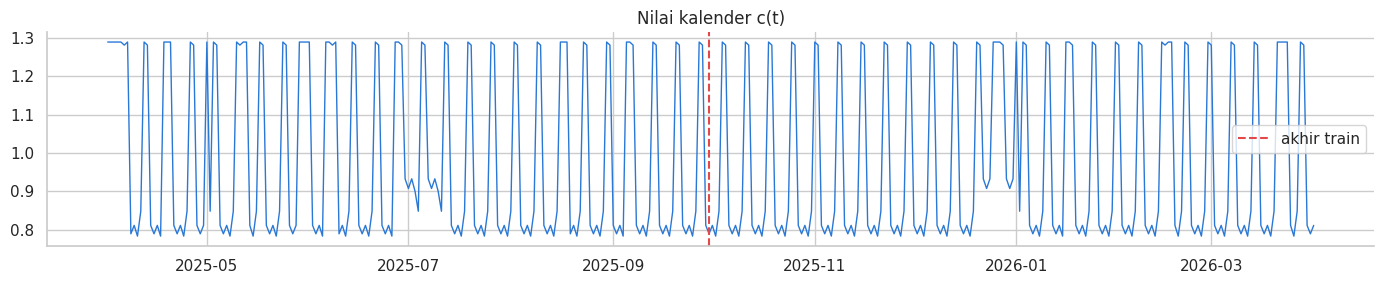

In [17]:
SCHOOL_BREAKS = [('2025-06-28', '2025-07-12'), ('2025-12-22', '2025-12-31')]
JABAR_BREAKS = [('2025-06-30', '2025-07-12'), ('2025-12-29', '2026-01-10')]
JABAR_CITIES = ['BOGOR', 'BEKASI', 'BANDUNG', 'DEPOK', 'CIKARANG', 'KARAWANG', 'CIREBON', 'GARUT', 'TASIKMALAYA',
                'SUMEDANG', 'CIANJUR', 'INDRAMAYU']
CUTI_BERSAMA = pd.to_datetime(['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07', '2025-05-13', '2025-05-30',
                               '2025-06-09', '2025-08-18', '2025-12-26', '2026-02-16', '2026-03-18', '2026-03-20',
                               '2026-03-23', '2026-03-24'])
RAMADAN = ('2026-02-19', '2026-03-20')


def calendar(hol, breaks=SCHOOL_BREAKS):
    c = hol.rename(columns={'date': 'date_show'})[['date_show', 'holiday_tipe']].copy()
    c['dow'] = c.date_show.dt.dayofweek
    c['is_hol'] = ((c.holiday_tipe == 'holiday') | c.date_show.isin(CUTI_BERSAMA)).astype(int)
    c['school'] = 0
    for a, b in breaks:
        c.loc[c.date_show.between(a, b), 'school'] = 1
    c['ramadan'] = c.date_show.between(*RAMADAN).astype(int)
    base = CFG.DOW_PROF[c.dow]
    base = np.where((c.school == 1) & (c.dow < 4), base * CFG.SCHOOL_WD, base)
    c['cal'] = np.where((c.is_hol == 1) & (c.ramadan == 0), np.maximum(base, CFG.HOL_LEVEL), base)
    return c.drop(columns='holiday_tipe').set_index('date_show')


CAL = calendar(hol)
CAL_JB = calendar(hol, JABAR_BREAKS)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(CAL.index, CAL.cal, lw=1)
ax.axvline(CFG.TRAIN_END, color=PAL[7], ls='--', label='akhir train')
ax.set(title='Nilai kalender c(t)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'cal_value.png'); plt.show()

## Fungsi Build Fitur

Kelompok fitur: (1) bentuk kurva pasangan D1 sampai D3, (2) agregat film nasional dan pangsa format, (3) kalender target dan riwayat, (4) jadwal rilis film lain, termasuk film baru yang dibuka di klaster yang sama pada tanggal target (terlihat di jendela D1 sampai D3 film tersebut), (5) ukuran klaster dan harga kota, (6) metadata film, (7) level relatif pasar (median film yang rilis 28 hari sebelumnya, gabungan jendela D1 sampai D3 train dan uji). Fitur level relatif v13 ditambahkan setelah `build` di sel berikutnya.

In [18]:
GENRES = ['Horror', 'Drama', 'Action', 'Comedy', 'Romance', 'Animation', 'Family', 'Thriller', 'Mystery']
RATING = {'Semua Umur': 0, 'Remaja': 1, 'Dewasa': 2, 'Dewasa 21': 3}


def film_table(vis):
    g = vis.groupby('movie_title')
    return pd.DataFrame({'d1': g.date_show.min(), 'occ': g.occupation_rate.mean(),
                         'tps': g.total_ticket.sum() / g.total_show.sum().clip(lower=1),
                         'logT': np.log1p(g.total_ticket.sum() / 3),
                         'lpc': np.log1p(g.total_ticket.sum() / 3 / g.cinema_ids.nunique().clip(lower=1))})


def make_ctx(visible, size_tx, market):
    rel = visible.assign(base=base_title(visible.movie_title)).groupby('base').agg(
        d1=('date_show', 'min'), tix=('total_ticket', 'sum')).reset_index()
    rel['tix'] /= 3
    cs = size_tx.groupby('cinema_ids').total_ticket.sum() / size_tx.groupby('cinema_ids').date_show.nunique()
    nf = size_tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = size_tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return dict(releases=rel, market=market, visible=visible, cin_size=np.log10(cs), cin_nfilms=nf, cin_shows=csh)


def cinema_comp(X, vis, cin_shows):
    v = vis.assign(base=base_title(vis.movie_title))
    agg = v.groupby(['cinema_ids', 'date_show', 'base']).agg(sh=('total_show', 'sum'), tx=('total_ticket', 'sum')).reset_index()
    m = X[['cinema_ids', 'date_show']].assign(base=base_title(X.movie_title)).reset_index().merge(
        agg, on=['cinema_ids', 'date_show'], how='left', suffixes=('', '_o'))
    m = m[m.base != m.base_o]
    g = m.groupby('index').agg(c_new_n=('base_o', 'nunique'), c_new_sh=('sh', 'sum'), c_new_tx=('tx', 'sum'))
    X = X.join(g).fillna({'c_new_n': 0, 'c_new_sh': 0, 'c_new_tx': 0})
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(cin_shows).fillna(X.c_new_sh.median() + 1)
    X['c_new_sh_vs_own'] = X.c_new_sh / X.sh3.clip(lower=1)
    X['c_new_tx_vs_own'] = np.log1p(X.c_new_tx) - np.log1p(X.y3)
    return X


def open_count(X, rel):
    d = np.sort(rel.d1.values.astype('datetime64[D]'))
    a = np.searchsorted(d, X.d1.values.astype('datetime64[D]'), side='right')
    b = np.searchsorted(d, X.date_show.values.astype('datetime64[D]'), side='right')
    return b - a


def build(hh, tgt, ctx):
    mv = movies.set_index('original_title')
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    hh = hh.join(d1, on='movie_title')
    hh['d'] = (hh.date_show - hh.d1).dt.days + 1
    piv = lambda v, p: hh.pivot_table(index=KEY, columns='d', values=v, fill_value=0).reindex(columns=[1, 2, 3], fill_value=0).add_prefix(p)
    P = pd.concat([piv('total_ticket', 'y'), piv('total_show', 'sh')], axis=1)
    P['mean3'] = P[['y1', 'y2', 'y3']].mean(axis=1)
    P['scale'] = P.mean3.clip(lower=1)
    P['log_s'] = np.log1p(P.mean3)
    for i in (1, 2, 3):
        P[f'p{i}'] = P[f'y{i}'] / P.scale
    P['n_hist'] = (P[['y1', 'y2', 'y3']] > 0).sum(axis=1)
    P['sh_trend'] = P.sh3 / P[['sh1', 'sh2']].max(axis=1).clip(lower=1)
    P = P.reset_index()

    Fd = hh.groupby(['movie_title', 'd']).agg(T=('total_ticket', 'sum'), nc=('cinema_ids', 'nunique')).unstack().fillna(0)
    Fd.columns = [f'f{a}{b}' for a, b in Fd.columns]
    Fd = Fd.reindex(columns=[f'f{a}{b}' for a in ['T', 'nc'] for b in (1, 2, 3)], fill_value=0)
    Fm = Fd[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1)
    for i in (1, 2, 3):
        Fd[f'fp{i}'] = Fd[f'fT{i}'] / Fm
    ncmax = Fd[['fnc1', 'fnc2', 'fnc3']].max(axis=1).clip(lower=1)
    Fd['f_logT'] = np.log1p(Fm)
    Fd['f_nc_trend'] = Fd.fnc3 / Fd.fnc1.clip(lower=1)
    Fd['f_occ'] = hh.groupby('movie_title').occupation_rate.mean()
    h3 = hh[hh.d == 3].groupby('movie_title')
    Fd['f_tps3'] = h3.total_ticket.sum() / h3.total_show.sum()
    Fd = Fd.join(d1)
    Fd['base'] = base_title(pd.Series(Fd.index, index=Fd.index))
    Fd['fmt'] = fmt(pd.Series(Fd.index, index=Fd.index)).map({'2D': 0, '3D': 1, 'IMAX 2D': 2, 'IMAX 3D': 3})
    bT = hh.assign(base=base_title(hh.movie_title)).groupby('base').total_ticket.sum() / 3
    Fd['fmt_share'] = np.log1p(Fm) - np.log1p(Fd.base.map(bT))
    Fd['d1_dow'] = Fd.d1.dt.dayofweek
    m = mv.reindex(Fd.base)
    Fd['rating'] = m.age_rating.map(RATING).values
    for g_ in GENRES:
        Fd[f'g_{g_}'] = m.genre.fillna('').str.contains(g_).astype(int).values
    Fd['n_genre'] = m.genre.fillna('').str.count(',').values + 1
    Fd['n_cast'] = m.casts.fillna('').str.count(',').values + 1
    rel = ctx['releases']
    Fd['comp_n'] = [((rel.base != r.base) & (rel.d1 > r.d1) & (rel.d1 <= r.d1 + pd.Timedelta(days=9))).sum() for _, r in Fd.iterrows()]
    Fd['f_share_cohort'] = np.log1p(Fd.base.map(bT)) - np.log1p(Fd.d1.map(rel.groupby('d1').tix.sum()))
    mk = ctx['market']
    win = lambda t: mk[(mk.d1 < t) & (mk.d1 >= t - pd.Timedelta(days=28))]
    Fd[['mk_occ', 'mk_tps', 'mk_logT', 'mk_lpc']] = [win(t)[['occ', 'tps', 'logT', 'lpc']].median().tolist() for t in Fd.d1]
    Fd['occ_rel'] = Fd.f_occ / Fd.mk_occ
    Fd['tps_rel'] = Fd.f_tps3 / Fd.mk_tps
    Fd['logT_rel'] = Fd.f_logT - Fd.mk_logT
    Fd['film_pc_vs_mkt'] = np.log1p(Fm / ncmax) - Fd.mk_lpc

    X = tgt.merge(P, on=KEY, how='left').merge(Fd.drop(columns=['base']), left_on='movie_title', right_index=True, how='left')
    X['h'] = (X.date_show - X.d1).dt.days + 1
    jb = (X.city_name.isin(JABAR_CITIES) & CFG.REGIONAL_CAL).values
    cal_at = lambda dates, col: np.where(jb, CAL_JB[col].reindex(dates).values, CAL[col].reindex(dates).values)
    X['dow'] = X.date_show.dt.dayofweek.values
    X['t_hol'], X['t_school'], X['t_ramadan'] = cal_at(X.date_show, 'is_hol'), cal_at(X.date_show, 'school'), cal_at(X.date_show, 'ramadan')
    ch = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'cal') for k in range(3)], 1)
    X['cal_mult'] = cal_at(X.date_show, 'cal') / ch.mean(1)
    X['hol_in_hist'] = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'is_hol') for k in range(3)], 1).sum(1)
    # D1-D3 tickets divided by the calendar value of their own day; labels and the MASE scale are untouched
    q = np.stack([X[f'y{i}'].values / cal_at(X.d1 + pd.Timedelta(days=i - 1), 'cal') for i in (1, 2, 3)], 1)
    for i in (1, 2, 3):
        X[f'cal_p{i}'] = q[:, i - 1] / np.maximum(q.mean(1), 1)
    X['cal_log31'] = np.log1p(q[:, 2]) - np.log1p(q[:, 0])
    X['n_comp_open'] = open_count(X, rel)
    X = cinema_comp(X, ctx['visible'], ctx['cin_shows'])
    X['share'] = X.log_s - np.log1p(X[['fT1', 'fT2', 'fT3']].mean(axis=1) / X.fnc3.clip(lower=1))
    X['pair_vs_mkt'] = X.log_s - X.mk_lpc
    X['p3_rel'] = X.p3 - X.fp3
    X['p1_rel'] = X.p1 - X.fp1
    X['cin_size'] = X.cinema_ids.map(ctx['cin_size'])
    X['cin_nfilms'] = X.cinema_ids.map(ctx['cin_nfilms'])
    X['cin_new'] = X.cin_size.isna().astype(int)
    pr = price.pivot(index='city_name', columns='price_day', values='ceil')
    X['price_wkd'] = X.city_name.map(pr.Weekday)
    X['price_prem'] = X.city_name.map(pr.Weekend / pr.Weekday)
    return X

Fitur dibangun untuk film rilis luas, film rilis terbatas (hanya latih), dan data uji. Tiga pemeriksaan wajib: jumlah baris tetap, urutan `id` uji tetap, dan skala sama persis dengan fungsi `hitung_skala` resmi.

In [19]:
market = pd.concat([film_table(vis_tr), film_table(hist)])
ctx_tr = make_ctx(vis_tr, train, market)
Xtr = build(hs, ts, ctx_tr)
Xlim = build(hl, tl, ctx_tr)
Xte = build(hist, test, make_ctx(hist, train, market))

assert len(Xtr) == len(ts) and len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
ref = Xte.join(pair_scale(hist), on=KEY, rsuffix='_ref')
assert np.allclose(ref.scale, ref.scale_ref)

BASE_FEATS = ['log_s', 'p1', 'p2', 'p3', 'n_hist', 'sh_trend', 'fnc1', 'fnc2', 'fnc3', 'fp1', 'fp2', 'fp3', 'f_logT',
              'f_nc_trend', 'fmt', 'fmt_share', 'd1_dow', 'rating'] + [f'g_{g_}' for g_ in GENRES] + [
              'n_genre', 'n_cast', 'comp_n', 'f_share_cohort', 'h', 'dow', 't_hol', 't_school', 't_ramadan', 'cal_mult',
              'hol_in_hist', 'n_comp_open', 'share', 'p3_rel', 'p1_rel', 'cin_size', 'cin_nfilms', 'cin_new',
              'price_wkd', 'price_prem']
COMP_FEATS = ['c_new_n', 'c_new_sh', 'c_new_sh_rel', 'c_new_sh_vs_own', 'c_new_tx_vs_own']
CAL_FEATS = ['cal_p1', 'cal_p2', 'cal_p3', 'cal_log31']
FEATS = BASE_FEATS
ZFEATS = FEATS + COMP_FEATS
jb_changed = Xte.t_school.values != CAL.school.reindex(Xte.date_show).values
print(f'West Java calendar: {jb_changed.sum()} test rows change school flag ({jb_changed.mean():.2%}); train rows changed: '
      f'{int((Xtr.t_school.values != CAL.school.reindex(Xtr.date_show).values).sum())}')
for X_ in (Xtr, Xlim, Xte):
    assert np.isfinite(X_[CAL_FEATS].values).all()
print('calendar-normalised inputs (median train | test):', {c: (round(float(Xtr[c].median()), 3), round(float(Xte[c].median()), 3)) for c in CAL_FEATS})
print(f'train {len(Xtr)} rows | limited extra {len(Xlim)} | test {len(Xte)} | features {len(FEATS)}')
display(pd.DataFrame({'train_median': Xtr[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median(),
                      'test_median': Xte[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median()}).round(3))

West Java calendar: 1134 test rows change school flag (1.56%); train rows changed: 202
calendar-normalised inputs (median train | test): {'cal_p1': (1.221, 1.213), 'cal_p2': (0.96, 0.944), 'cal_p3': (0.797, 0.814), 'cal_log31': (-0.423, -0.392)}
train 56372 rows | limited extra 1435 | test 72611 | features 47


,train_median,test_median
log_s,5.204,4.529
f_logT,9.974,9.450
pair_vs_mkt,0.019,-0.123
film_pc_vs_mkt,0.353,0.286
share,-0.379,-0.435


## Fitur Relatif dan Genre Lengkap

Fitur relatif lama tetap dihitung untuk audit, tetapi tidak dipakai kontrol. Token genre lengkap diambil dari `movies.csv` resmi dan dipetakan ke judul dasar, termasuk format IMAX/3D. Kandidat genre menambah token yang belum ada dalam sembilan flag baseline dan flag metadata tidak tersedia. Kosakata tidak memakai label target.

brute-force check of the cluster reference passed (80 rows); fallback to national reference: {'train': 0.0006, 'limited': 0.0, 'test': 0.001}


,train_median,test_median,shift,ks
feature,,,,
log_s,5.204,4.529,-0.675,0.231
f_logT,9.974,9.450,-0.524,0.236
rel_nat,0.307,0.229,-0.078,0.042
rel_clu,0.286,0.199,-0.087,0.043
f_rel,0.677,0.501,-0.176,0.105


cluster reference median (tickets/day): train 141 | test 77


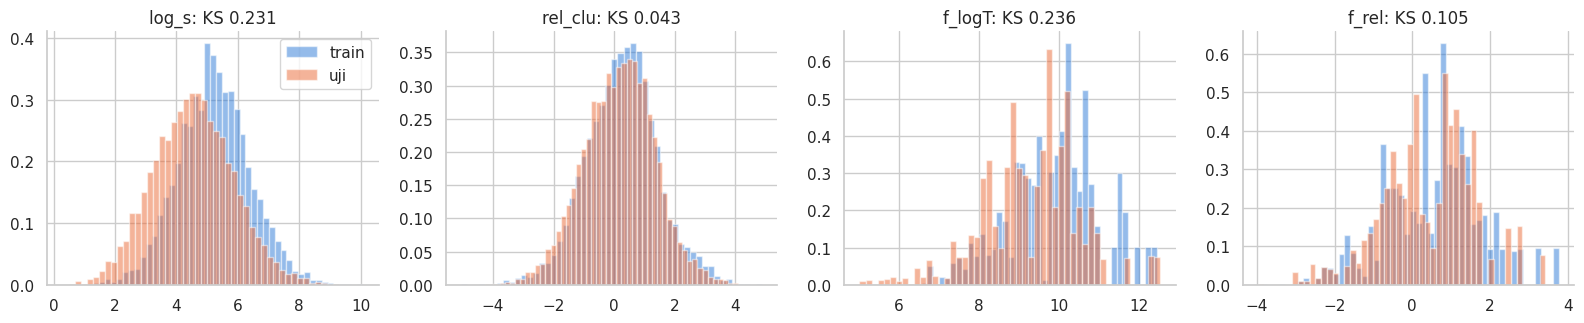

Additional official genre tokens: ['Adventure', 'Biography', 'Crime', 'Disaster', 'Documentary', 'Fantasy', 'Gothic', 'History', 'Live Stream', 'Music', 'Musical', 'Religi', 'Sci-Fi', 'Sport', 'Superhero', 'Survival', 'Suspense', 'Teen', 'War', 'eSport']


In [20]:
REL_FEATS = ['rel_nat', 'rel_clu', 'f_rel']
ABS_LEVEL = ['log_s', 'f_logT']


def add_relative(X):
    X = X.copy()
    X['ref_clu'], X['ref_nat'] = ref_cluster(X, 'sc'), ref_national(X, VP, 'sc')
    ls = np.log(X.scale.values)
    X['rel_nat'] = ls - np.log(np.clip(X.ref_nat.values, 1, None))
    X['rel_clu'] = np.where(np.isfinite(X.ref_clu), ls - np.log(np.clip(X.ref_clu.values, 1, None)), X.rel_nat)
    fm = X[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1).values
    X['f_rel'] = np.log(fm) - np.log(np.clip(ref_national(X, VF, 'ft'), 1, None))
    return X


Xtr, Xlim, Xte = add_relative(Xtr), add_relative(Xlim), add_relative(Xte)
assert len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
assert all(np.isfinite(X_[REL_FEATS].values).all() for X_ in (Xtr, Xlim, Xte))
FEATS_ABS = BASE_FEATS
FEATS_REL = [f for f in BASE_FEATS if f not in ABS_LEVEL] + REL_FEATS

rng_ = np.random.default_rng(CFG.SEED)
for X_ in (Xtr, Xte):
    for i in rng_.choice(len(X_), 40, replace=False):
        r_ = X_.iloc[i]
        k = (VP.cinema_ids == r_.cinema_ids) & ((VP.d1 - r_.d1).dt.days.abs() <= CFG.REL_WIN) & (VP.base != base_title(pd.Series([r_.movie_title]))[0])
        ref_bf = VP.sc[k].median() if k.sum() >= 2 else np.nan
        assert np.isclose(ref_bf, r_.ref_clu, equal_nan=True), (r_.movie_title, r_.cinema_ids)
print('brute-force check of the cluster reference passed (80 rows); fallback to national reference:',
      {n: round(float(np.isnan(X_.ref_clu).mean()), 4) for n, X_ in [('train', Xtr), ('limited', Xlim), ('test', Xte)]})

kt = pd.DataFrame([dict(feature=c, train_median=Xtr[c].median(), test_median=Xte[c].median(),
                        shift=Xte[c].median() - Xtr[c].median(), ks=ks_2samp(Xtr[c], Xte[c]).statistic)
                   for c in ABS_LEVEL + REL_FEATS]).set_index('feature')
display(kt.round(3))
print(f'cluster reference median (tickets/day): train {np.nanmedian(Xtr.ref_clu):.0f} | test {np.nanmedian(Xte.ref_clu):.0f}')
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a_, c in zip(ax, ['log_s', 'rel_clu', 'f_logT', 'f_rel']):
    a_.hist(Xtr[c], bins=50, density=True, alpha=.5, label='train'); a_.hist(Xte[c], bins=50, density=True, alpha=.5, label='uji')
    a_.set(title=f"{c}: KS {kt.loc[c, 'ks']:.3f}")
ax[0].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'relative_features.png'); plt.show()

META = movies.copy()
META['original_title'] = META.original_title.str.strip()
assert META.original_title.is_unique
META = META.set_index('original_title')
GENRE_TOKENS = META.genre.fillna('').str.split(',').map(lambda z: {v.strip() for v in z if v.strip()})
EXTRA_GENRES = sorted(set().union(*GENRE_TOKENS) - set(GENRES))
EXTRA_GENRE_FEATS = [f'genre_extra_{i}' for i in range(len(EXTRA_GENRES))] + ['metadata_missing']

def complete_genres(X):
    X = X.copy()
    b = base_title(X.movie_title)
    tokens = b.map(GENRE_TOKENS).map(lambda z: z if isinstance(z, set) else set())
    for i, token in enumerate(EXTRA_GENRES):
        X[f'genre_extra_{i}'] = tokens.map(lambda z: int(token in z))
    X['metadata_missing'] = (~b.isin(META.index) | b.map(META.genre).isna()).astype(int)
    assert np.isfinite(X[EXTRA_GENRE_FEATS].values).all()
    return X

Xtr, Xlim, Xte = [complete_genres(X_) for X_ in (Xtr, Xlim, Xte)]
print('Additional official genre tokens:', EXTRA_GENRES)


#### Insights

> Audit menunjukkan baris dengan genre terbuang membawa 26,1% error v16. Namun 78,7% kontribusi error Adventure berasal dari satu film. Angka ini alasan untuk ablation, bukan bukti bahwa genre akan memperbaiki generalisasi.

## Verifikasi Drift: Adversarial Validation

Classifier dilatih membedakan baris simulasi dari baris uji dengan fold dikelompokkan per film (split acak memberi AUC palsu 1,0 karena fitur level film konstan dalam satu film).

In [21]:
def adv_auc(cols):
    A = pd.concat([Xtr[cols].assign(t=0, g=Xtr.movie_title), Xte[cols].assign(t=1, g=Xte.movie_title)], ignore_index=True)
    oof = np.zeros(len(A))
    for a, b in StratifiedGroupKFold(5, shuffle=True, random_state=CFG.SEED).split(A, A.t, A.g):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=CFG.SEED, verbose=-1)
        oof[b] = m.fit(A.iloc[a][cols], A.t.iloc[a]).predict_proba(A.iloc[b][cols])[:, 1]
    return roc_auc_score(A.t, oof)


shape_cols = ['p1', 'p2', 'p3', 'fp1', 'fp3', 'share', 'sh_trend', 'd1_dow', 'n_hist']
print(f"AUC shape features only:         {adv_auc(shape_cols):.3f}")
print(f"AUC + absolute level (log_s, f_logT): {adv_auc(shape_cols + ['log_s', 'f_logT']):.3f}")
print(f"AUC + market-relative level:     {adv_auc(shape_cols + ['pair_vs_mkt', 'film_pc_vs_mkt']):.3f}")
print(f"AUC + v13 relative level:        {adv_auc(shape_cols + REL_FEATS):.3f}")
print(f"AUC full feature set, absolute:  {adv_auc(FEATS_ABS):.3f}")
print(f"AUC full feature set, relative:  {adv_auc(FEATS_REL):.3f}")

AUC shape features only:         0.510
AUC + absolute level (log_s, f_logT): 0.544
AUC + market-relative level:     0.479
AUC + v13 relative level:        0.467
AUC full feature set, absolute:  0.733
AUC full feature set, relative:  0.649


#### Insights

> Fitur bentuk kurva tidak bisa membedakan train dan uji (AUC sekitar 0,51). Level absolut menaikkan AUC karena pasar uji lebih sepi, sedangkan level relatif tidak. Pada set fitur lengkap, sisa AUC berasal dari fitur lain yang memang berbeda antarperiode (kalender, jadwal rilis, cakupan klaster), bukan dari level pasangan. Penurunan AUC set lengkap dari absolut ke relatif menunjukkan seberapa besar pergeseran yang dihapus oleh penggantian dua fitur level.

---

# Modeling <a name="8"></a>

---

Kontrol dan dua kandidat dilatih ulang pada split identik. Validasi baru tidak dapat dihitung dengan sekadar mengelompokkan ulang prediksi OOF lama. Seluruh fitting berjalan di Kaggle.

## Dasar Eksperimen

Dua hipotesis dibekukan sebelum run. Genre resmi memiliki 29 token, sementara baseline hanya memakai sembilan. Model per horizon juga membagi pembelajaran menjadi tujuh masalah terpisah; kandidat pooled menguji apakah berbagi konteks membantu lintasan D4 sampai D10. Jumlah baris konteks dibatasi untuk T4, sehingga ini menguji resep pooling beserta samplingnya, bukan efek pooling murni. Eksperimen 47 terdahulu pada satu fold dan dua horizon justru menemukan pooled 45 ribu baris lebih buruk dan 17 kali lebih lambat. Kandidat ini adalah pemeriksaan ulang dengan batas konteks dan validasi lebih luas, bukan metode yang sudah terbukti unggul.

#### Insights

> Tidak ada data eksternal baru yang masuk fitur. Pemeriksaan tanggal rilis eksternal pada beberapa film bererror besar cocok dengan D1 simulator; cakupannya belum membuktikan semua D1 benar.

## Validasi Blok Waktu dan Backtest

Minggu rilis diurutkan lalu dibagi menjadi lima blok berurutan. Semua jendela D1 sampai D10 train yang menyentuh rentang validasi dikeluarkan, termasuk limited. Statistik klaster mengeluarkan film validasi dan transaksi dalam rentang blok tersebut. Ini stress test kohort dengan train sebelum maupun sesudah blok, bukan forecasting kronologis. Backtest terpisah pada Mei sampai September hanya memakai target yang selesai sebelum awal bulan. Mei hanya memiliki sekitar sepuluh film latih dan dilaporkan sebagai cold-start stress; rerata Juni–September dan Juli–September juga disimpan. Rekonstruksi D1 masih memakai aturan cakupan lama yang melihat seluruh riwayat.

In [22]:
groups = base_title(Xtr.movie_title).values
WEEK = ((Xtr.d1 - pd.Timestamp('2025-03-31')).dt.days // 7).values
weeks_ = np.array(sorted(set(WEEK)))
fold_of_week = {w: k for k, block in enumerate(np.array_split(weeks_, CFG.N_FOLDS)) for w in block}
FOLD = np.array([fold_of_week[w_] for w_ in WEEK])
assert pd.Series(FOLD).groupby(groups).nunique().max() == 1
y, s, cm, hh_ = Xtr.total_ticket.values, Xtr.scale.values, Xtr.cal_mult.values, Xtr.h.values

fday = lambda D: pd.Series(np.where(D.y1 > 0, 1, np.where(D.y2 > 0, 2, 3)), index=D.index)
cell = lambda D: pd.cut(D.scale, CFG.TW_BINS).astype(str) + '|' + fday(D).astype(str)
tw = cell(Xtr).map(cell(Xte).value_counts(normalize=True) / cell(Xtr).value_counts(normalize=True)).fillna(0).astype(float).values
TW = tw / tw.mean()
fold_tab = pd.DataFrame({'films': pd.Series(groups).groupby(FOLD).nunique(), 'weeks': pd.Series(WEEK).groupby(FOLD).nunique(),
                         'rows': pd.Series(FOLD).value_counts().sort_index(), 'TW share': pd.Series(TW).groupby(FOLD).sum() / TW.sum()})
display(fold_tab.round(3))


def score(p, name):
    e = np.abs(y - p) / s
    r = dict(model=name, MASE=e.mean(), TW_MASE=np.average(e, weights=TW), small=e[s <= 20].mean(), big=e[s > 200].mean())
    print(f"{name:40s} MASE {r['MASE']:.4f} | TW-MASE {r['TW_MASE']:.4f} | s<=20 {r['small']:.4f} | s>200 {r['big']:.4f}")
    return r


def train_part(k):
    v = FOLD == k
    lo, hi = Xtr.d1[v].min(), Xtr.d1[v].max() + pd.Timedelta(days=9)
    excluded = set(groups[v])
    ready = lambda X: X[((X.d1 + pd.Timedelta(days=9) < lo) | (X.d1 > hi)) & ~base_title(X.movie_title).isin(excluded)]
    a = pd.concat([ready(Xtr), ready(Xlim)], ignore_index=True) if CFG.USE_LIMITED else ready(Xtr)
    assert ((a.d1 + pd.Timedelta(days=9) < lo) | (a.d1 > hi)).all()
    assert not set(base_title(a.movie_title)) & excluded
    return a


results = []
rc = y / s / cm
oof_base = np.zeros(len(Xtr))
for k in range(CFG.N_FOLDS):
    b = FOLD == k
    lo, hi = Xtr.d1[b].min(), Xtr.d1[b].max() + pd.Timedelta(days=9)
    a = ((Xtr.d1 + pd.Timedelta(days=9) < lo) | (Xtr.d1 > hi)).values
    med = pd.Series(rc[a]).groupby([hh_[a], Xtr.d1_dow.values[a]]).median()
    oof_base[b] = med.reindex(pd.MultiIndex.from_arrays([hh_[b], Xtr.d1_dow.values[b]])).fillna(np.median(rc[a])).values * cm[b] * s[b]
results.append(score(oof_base, 'median r/c by (h, D1 dow)'))

,films,weeks,rows,TW share
0,24,5,10710,0.181
1,26,5,10942,0.181
2,30,5,12866,0.224
3,24,4,11599,0.204
4,22,4,10255,0.210


median r/c by (h, D1 dow)                MASE 0.3967 | TW-MASE 0.4298 | s<=20 0.9802 | s>200 0.3236


## Offset Pencopotan dari Proxy Periode Uji

Klasifier proxy (D3 dari D1 dan D2) dilatih pada train dan dinilai pada pasangan periode uji, sama seperti v4 sampai v13. Offset logit $a$ dipakai oleh koreksi $\lambda a$ yang diuji per model.

In [23]:
for Pp in (PA, PB):
    c3 = np.stack([CAL.cal.reindex(Pp.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1)
    Pp['cm'] = c3[:, 2] / c3[:, :2].mean(1)
PCOLS = ['q1', 'q2', 'log_s', 'sh1', 'sh2', 'sh_tr', 'occ2', 'f_tr', 'f_log', 'f_nc', 'cm', 'd1_dow']
clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=100, verbose=-1,
                         deterministic=True, force_row_wise=True, random_state=CFG.SEED).fit(PA[PCOLS], PA.y == 0)
pB0 = np.clip(clf.predict_proba(PB[PCOLS])[:, 1], 1e-4, 1 - 1e-4)
zB = (PB.y == 0).values
PULL_A = float(grid_a[np.argmin([nll(pB0, zB, a) for a in grid_a])])
print(f'pull-odds shift a = {PULL_A:.3f} (odds x {np.exp(PULL_A):.2f}); mean p0 {pB0.mean():.3f} -> shifted {sigm(logit(pB0) + PULL_A).mean():.3f} | observed {zB.mean():.3f}')

pull-odds shift a = -1.320 (odds x 0.27); mean p0 0.146 -> shifted 0.085 | observed 0.085


## Statistik Klaster pada Split Baru

Statistik ukuran klaster dan jumlah show dihitung ulang tanpa film validasi dan tanpa transaksi pada interval validasi. Ini memperbaiki pemisahan informasi tingkat kalender. Fitur pesaing dari jendela history resmi tetap tersedia sebagaimana paket kompetisi batch, bukan skenario produksi online.

In [24]:
def cin_stats(tx):
    cs = tx.groupby('cinema_ids').total_ticket.sum() / tx.groupby('cinema_ids').date_show.nunique()
    nf = tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return np.log10(cs), nf, csh


def with_cin(X, stats):
    cs, nf, csh = stats
    X = X.copy()
    X['cin_size'] = X.cinema_ids.map(cs)
    X['cin_nfilms'] = X.cinema_ids.map(nf)
    X['cin_new'] = X.cin_size.isna().astype(int)
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(csh).fillna(X.c_new_sh.median() + 1)
    return X


TRAIN_BASE = base_title(train.movie_title)
STATS_ALL = cin_stats(train)
assert np.allclose(with_cin(Xtr, STATS_ALL).cin_size.fillna(-9), Xtr.cin_size.fillna(-9))
STATS_FOLD = {}
split_manifest = []
for k in range(CFG.N_FOLDS):
    v = FOLD == k
    lo, hi = Xtr.d1[v].min(), Xtr.d1[v].max() + pd.Timedelta(days=9)
    excluded = set(groups[v])
    raw_ok = ~TRAIN_BASE.isin(excluded) & ~train.date_show.between(lo, hi)
    STATS_FOLD[k] = cin_stats(train[raw_ok])
    for role, frame in [('train', train_part(k)), ('validation', Xtr[v])]:
        for title in frame.movie_title.unique():
            split_manifest.append(dict(fold=k, role=role, movie_title=title, start=lo, end=hi))
pd.DataFrame(split_manifest).to_csv(CFG.OUTPUT_DIR / 'split_manifest.csv', index=False)
rk = np.mean([pd.Series(with_cin(Xtr[FOLD == k], STATS_FOLD[k]).cin_size.values).corr(pd.Series(Xtr.cin_size[FOLD == k].values), method='spearman') for k in range(CFG.N_FOLDS)])
print(f'rank correlation of cin_size, global vs fold-local: {rk:.4f}')

rank correlation of cin_size, global vs fold-local: 0.9986


## Mesin Evaluasi dan Kontrol LightGBM

LightGBM sama dengan v8 sampai v13: L1 (3 seed) ditambah hurdle (klasifier $p_0$ dengan fitur kompetisi klaster dan 19 regresi kuantil bagian positif), bobot hurdle 0,75, $\lambda = 0{,}5$. `run_cv` menjalankan CV kohort dan `temporal` backtest bulanan; bagian latih disimpan agar semua kandidat model memakai fold yang persis sama.

In [25]:
LGB_BASE = {k: v for k, v in CFG.LGB_PARAMS.items() if k not in ('objective', 'n_estimators')}
LGB_FAST = {**LGB_BASE, 'n_estimators': 300, 'learning_rate': 0.05}
MONTHS = ['2025-05', '2025-06', '2025-07', '2025-08', '2025-09']
FEATS = FEATS_ABS
ZFEATS = FEATS + COMP_FEATS


def r_target(Xa):
    return (Xa.total_ticket / Xa.scale / Xa.cal_mult).values


def fit_lgb_all(Xa):
    l1 = [lgb.LGBMRegressor(objective='l1', n_estimators=CFG.LGB_PARAMS['n_estimators'], **LGB_BASE, random_state=sd)
          .fit(Xa[FEATS], r_target(Xa), sample_weight=Xa.cal_mult.values) for sd in CFG.SEEDS]
    zc = lgb.LGBMClassifier(objective='binary', **{**LGB_FAST, 'num_leaves': 31}, random_state=CFG.SEED).fit(Xa[ZFEATS], Xa.total_ticket == 0)
    pos = Xa[Xa.total_ticket > 0]
    qm = [lgb.LGBMRegressor(objective='quantile', alpha=float(q), **LGB_FAST, random_state=CFG.SEED).fit(pos[FEATS], r_target(pos))
          for q in CFG.QS]
    return dict(l1=l1, zc=zc, qm=qm)


def lgb_size_mb(m):
    return sum(len(zlib.compress(x.booster_.model_to_string().encode(), 9)) for x in m['l1'] + [m['zc']] + m['qm']) / 1e6


def predict_lgb_all(m, Xb):
    l1 = np.clip(np.mean([mm.predict(Xb[FEATS]) for mm in m['l1']], 0), 0, None)
    p0 = m['zc'].predict_proba(Xb[ZFEATS])[:, 1]
    Q = np.sort(np.column_stack([mm.predict(Xb[FEATS]) for mm in m['qm']]), axis=1)
    return l1, p0, Q


def mixture_median(p0, Q, qs, lam):
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    t = np.clip((0.5 - p) / (1 - p), qs[0], qs[-1])
    val = np.array([np.interp(ti, qs, qi) for ti, qi in zip(t, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


def lgb_mix(l1, p0, Q, lam=None):
    lam = CFG.LAMBDA if lam is None else lam
    return (1 - CFG.HURDLE_W) * l1 + CFG.HURDLE_W * mixture_median(p0, Q, CFG.QS, lam)


def run_cv():
    oof = dict(l1=np.zeros(len(Xtr)), p0=np.zeros(len(Xtr)), Q=np.zeros((len(Xtr), len(CFG.QS))))
    frames, size = {}, 0.0
    for k in range(CFG.N_FOLDS):
        v = FOLD == k
        Xa, Xb = with_cin(train_part(k), STATS_FOLD[k]), with_cin(Xtr[v], STATS_FOLD[k])
        m = fit_lgb_all(Xa)
        oof['l1'][v], oof['p0'][v], oof['Q'][v] = predict_lgb_all(m, Xb)
        frames[k] = (Xa, Xb)
        size = max(size, lgb_size_mb(m))
    return oof, frames, size


def temporal():
    out = {}
    for mth in MONTHS:
        cut = pd.Timestamp(mth + '-01')
        va = (Xtr.d1.dt.strftime('%Y-%m') == mth).values
        ready = lambda X: X[(X.d1 + pd.Timedelta(days=9) < cut).values]
        Xa = pd.concat([ready(Xtr), ready(Xlim)], ignore_index=True) if CFG.USE_LIMITED else ready(Xtr)
        stats = cin_stats(train[train.date_show < cut])
        assert (Xa.d1 + pd.Timedelta(days=9) < cut).all()
        assert not set(base_title(Xa.movie_title)) & set(base_title(Xtr.loc[va, 'movie_title']))
        Xa_, Xb_ = with_cin(Xa, stats), with_cin(Xtr[va], stats)
        out[mth] = dict(idx=np.where(va)[0], parts=predict_lgb_all(fit_lgb_all(Xa_), Xb_), frames=(Xa_, Xb_))
    return out


def lgb_component(R, lam=None):
    o = R['oof']
    tp = {m: (t['idx'], lgb_mix(*t['parts'], lam=lam) * cm[t['idx']] * s[t['idx']]) for m, t in R['temporal'].items()}
    return lgb_mix(o['l1'], o['p0'], o['Q'], lam=lam) * cm * s, tp


def lens(p, tpred):
    e = np.abs(y - p) / s
    r = dict(TW=np.average(e, weights=TW), MASE=e.mean())
    r.update({f'fold{k}': np.average(e[FOLD == k], weights=TW[FOLD == k]) for k in range(CFG.N_FOLDS)})
    tm = {m: np.average(np.abs(y[i] - pr) / s[i], weights=TW[i]) for m, (i, pr) in tpred.items()}
    r.update({f'temp_{m}': v for m, v in tm.items()})
    r['temporal_mean'] = np.mean(list(tm.values()))
    r['temporal_jun_sep'] = np.mean([v for m, v in tm.items() if m >= '2025-06'])
    r['temporal_jul_sep'] = np.mean([v for m, v in tm.items() if m >= '2025-07'])
    return r


def blend(ws, comps):
    p = sum(w_ * comps[n][0] for n, w_ in ws.items())
    tp = {m: (i, sum(w_ * comps[n][1][m][1] for n, w_ in ws.items())) for m, (i, _) in comps['lgb'][1].items()}
    return p, tp


t0 = time.time()
oof_, frames_, size_ = run_cv()
SEL = dict(oof=oof_, frames=frames_, temporal=temporal(), lgb_mb=size_)
SEL['comp'] = lgb_component(SEL)
SELECTED = 'B1 cohort CV'
print(f'LightGBM control: {time.time() - t0:.0f}s | size {size_:.1f} MB')
display(pd.DataFrame({'LightGBM': lens(*SEL['comp'])}).T.round(4))

LightGBM control: 576s | size 20.1 MB


,TW,MASE,fold0,fold1,fold2,fold3,fold4,temp_2025-05,temp_2025-06,temp_2025-07,temp_2025-08,temp_2025-09,temporal_mean,temporal_jun_sep,temporal_jul_sep
LightGBM,0.3472,0.33,0.4584,0.3973,0.3189,0.2998,0.2847,0.5033,0.3121,0.3271,0.2885,0.3018,0.3466,0.3074,0.3058


Sensitivitas $\lambda$ LightGBM (dibekukan 0,5) pada kedua lensa, hanya untuk informasi.

In [26]:
display(pd.DataFrame({lam: lens(*lgb_component(SEL, lam)) for lam in (0.0, 0.25, 0.5, 0.75, 1.0)}).T[['TW', 'temporal_mean']].round(4))
oof_lgbmix = SEL['comp'][0]
results.append(score(oof_lgbmix, 'LightGBM mix (cohort CV)'))

,TW,temporal_mean
0.00,0.3432,0.3428
0.25,0.3446,0.3439
0.50,0.3472,0.3466
0.75,0.3510,0.3494
1.00,0.3561,0.3537


LightGBM mix (cohort CV)                 MASE 0.3300 | TW-MASE 0.3472 | s<=20 0.8353 | s>200 0.2774


## Kandidat Foundation Model

`tp35_int7` menjadi kontrol per horizon, `tp35_genre` menambah genre resmi lengkap, dan `tp35_pool` memakai satu konteks lintas horizon dengan fitur baseline. Ketiganya memakai satu checkpoint int7 yang identik dan tidak memakai log1p. Paling banyak satu varian masuk berkas final. Tidak ada AI API untuk inference.

In [27]:
TAB_QS = CFG.TAB_QS


def hf_token():
    if os.environ.get('HF_TOKEN'):
        return os.environ['HF_TOKEN']
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret('HF_TOKEN')
        except Exception:
            return None
    return None


def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


def find_local(fname):
    roots = [Path('/kaggle/input')] if CFG._ON_KAGGLE else []
    for root in roots:
        hit = [p for p in root.rglob(Path(fname).name) if str(p).endswith(fname)]
        if hit:
            return str(hit[0])
        for pk in root.rglob('*.pkl'):
            try:
                with open(pk, 'rb') as f:
                    blob = pickle.load(f).get('fm_files', {})
            except Exception:
                continue
            if fname in blob:
                out = CFG.OUTPUT_DIR / 'fm' / fname
                out.parent.mkdir(parents=True, exist_ok=True)
                out.write_bytes(blob[fname])
                return str(out)
    return None


def checkpoint_path(repo, fname, rev, digest):
    # local_dir keeps the real file name: loaders pick the format from the suffix
    path = find_local(fname) or hf_hub_download(repo, fname, revision=rev, token=hf_token(), local_dir=str(CFG.OUTPUT_DIR / 'fm'))
    got = sha256(path)
    if got != digest:
        raise RuntimeError(f'{fname}: SHA-256 {got} does not match the pinned revision ({digest})')
    print(f'{fname}: SHA-256 verified ({path})')
    return path


def fast16_checkpoint():
    hit = find_local(CFG.FAST16_FILE)
    if hit:
        return hit
    src = checkpoint_path(CFG.FAST_REPO, CFG.FAST_FILE, CFG.FAST_REV, CFG.FAST_SHA256)
    out = CFG.OUTPUT_DIR / 'fm' / CFG.FAST16_FILE
    out.parent.mkdir(parents=True, exist_ok=True)
    with safe_open(src, framework='np') as f:
        meta = f.metadata()
        arrays = {k_: (lambda a: a.astype(np.float16) if (a.dtype == np.float32 and a.ndim >= 2) else a)(f.get_tensor(k_)) for k_ in f.keys()}
    save_file(arrays, str(out), metadata=meta)
    Path(src).unlink()
    print(f'{CFG.FAST16_FILE}: {out.stat().st_size / 1e6:.1f} MB')
    return str(out)


def tp35_pack(src):
    lev = 2 ** (CFG.TP35_BITS - 1) - 1
    tensors, e2, r2 = {}, 0.0, 0.0
    with safe_open(src, framework='np') as f:
        meta = f.metadata()
        for k_ in f.keys():
            a = f.get_tensor(k_)
            if a.dtype == np.float32 and a.ndim >= 2:
                m = a.reshape(a.shape[0], -1)
                sc = (np.abs(m).max(axis=1, keepdims=True) / lev).astype(np.float16)
                sc[sc == 0] = 1
                q = np.clip(np.round(m / sc.astype(np.float32)), -lev, lev).astype(np.int8)
                e2 += float(np.square(q * sc.astype(np.float32) - m.astype(np.float64)).sum())
                r2 += float(np.square(m.astype(np.float64)).sum())
                tensors[k_] = ('q', a.shape, zlib.compress(q.tobytes(), 9), sc.tobytes())
            else:
                tensors[k_] = ('raw', a.shape, a.dtype.str, a.tobytes())
    print(f'int{CFG.TP35_BITS} per-row quantisation: relative L2 weight error {np.sqrt(e2 / r2):.4f}')
    return pickle.dumps({'meta': meta, 'bits': CFG.TP35_BITS, 'tensors': tensors})


def tp35_unpack(blob, out_path):
    d = pickle.loads(blob)
    arrays = {}
    for k_, v in d['tensors'].items():
        if v[0] == 'q':
            q = np.frombuffer(zlib.decompress(v[2]), dtype=np.int8).reshape(v[1][0], -1)
            sc = np.frombuffer(v[3], dtype=np.float16).astype(np.float32).reshape(-1, 1)
            arrays[k_] = (q.astype(np.float32) * sc).reshape(v[1])
        else:
            arrays[k_] = np.frombuffer(v[3], dtype=np.dtype(v[2])).reshape(v[1]).copy()
    save_file(arrays, str(out_path), metadata=d['meta'])


TP35_FP32 = None


def tp35_checkpoint():
    global TP35_FP32
    pack_path = find_local(CFG.TP35_PACK)
    if pack_path is None:
        TP35_FP32 = checkpoint_path(CFG.TP35_REPO, CFG.TP35_FILE, CFG.TP35_REV, CFG.TP35_SHA256)
        pack_path = CFG.OUTPUT_DIR / 'fm' / CFG.TP35_PACK
        pack_path.write_bytes(tp35_pack(TP35_FP32))
    out = CFG.OUTPUT_DIR / 'fm' / f'tabpfn-v3.5-full-int{CFG.TP35_BITS}-dequant.safetensors'
    tp35_unpack(Path(pack_path).read_bytes(), out)
    print(f'{CFG.TP35_PACK}: {Path(pack_path).stat().st_size / 1e6:.1f} MB packed, SHA-256 {sha256(pack_path)}')
    return str(out), str(pack_path)


def causilo_checkpoint():
    paths = {f_: checkpoint_path(CFG.CAUSILO_REPO, f_, CFG.CAUSILO_REV, h_) for f_, h_ in CFG.CAUSILO_FILES.items()}
    reg_dir = Path(paths['regressor/model.safetensors']).parent
    # load the SHA-verified local copy instead of the package's own Hub download
    causilo_ckpt.load_pretrained_model = lambda task: causilo_ckpt.load_checkpoint(reg_dir)
    return paths


def make_tabpfn(version, ckpt, n_est, variant='tp35_int7'):
    def fn(Xa, Xb):
        pooled = variant == 'tp35_pool'
        tf = list(FEATS) if pooled else [c for c in FEATS if c != 'h']
        if variant == 'tp35_genre':
            tf += EXTRA_GENRE_FEATS
        out = np.zeros((len(Xb), len(TAB_QS)))
        if pooled:
            pieces = []
            for hz in range(4, 11):
                part = Xa[Xa.h == hz].sort_values(['movie_title', 'cinema_ids', 'h'])
                pieces.append(part.sample(n=min(len(part), CFG.POOL_CONTEXT // 7), random_state=CFG.SEED + hz))
            context = pd.concat(pieces, ignore_index=True)
            assert len(context) <= CFG.POOL_CONTEXT and not context.duplicated(KEY + ['h']).any()
            print(f'pooled context {len(context)}/{len(Xa)} rows | {base_title(context.movie_title).nunique()} base films')
        else:
            context = Xa
        for hz in ([None] if pooled else range(4, 11)):
            a = context if hz is None else context[context.h == hz]
            ib = np.ones(len(Xb), dtype=bool) if hz is None else (Xb.h == hz).values
            if not ib.any():
                continue
            assert len(a) > 0
            m = TabPFNRegressor.create_default_for_version(version, model_path=ckpt, device=CFG.DEVICE,
                    n_estimators=n_est, random_state=CFG.SEED, ignore_pretraining_limits=True)
            m.fit(a[tf].values.astype(np.float32), r_target(a))
            B = Xb.loc[ib, tf].values.astype(np.float32)
            out[ib] = np.concatenate([np.asarray(m.predict(B[i:i + 3000], output_type='quantiles', quantiles=list(TAB_QS))).T
                                     for i in range(0, len(B), 3000)])
            del m
            torch.cuda.empty_cache()
        assert np.isfinite(out).all()
        return np.sort(out, axis=1)
    return fn


def make_causilo(pooled):
    def fn(Xa, Xb):
        tf = FEATS if pooled else [c for c in FEATS if c != 'h']
        ya = np.log1p(np.clip(r_target(Xa), 0, None))
        out = np.zeros((len(Xb), len(TAB_QS)))
        for hz in ([None] if pooled else range(4, 11)):
            ia = np.ones(len(Xa), bool) if hz is None else (Xa.h == hz).values
            ib = np.ones(len(Xb), bool) if hz is None else (Xb.h == hz).values
            if ib.sum() == 0:
                continue
            m = CausiloRegressor(n_estimators=CFG.CAUSILO_EST, random_state=CFG.SEED, device=CFG.DEVICE)
            m.fit(Xa[ia][tf].values.astype(np.float32), ya[ia])
            Qb = Xb[ib][tf].values.astype(np.float32)
            q = np.concatenate([m.predict(Qb[i:i + 2000], output_type='quantiles', quantiles=list(TAB_QS)) for i in range(0, len(Qb), 2000)])
            out[ib] = np.expm1(q)
            del m
            torch.cuda.empty_cache()
        return np.sort(np.clip(out, 0, None), axis=1)
    return fn


def quant_median(Q, lam):
    p0 = np.array([np.interp(CFG.ZERO_EPS, q, TAB_QS, left=0.0, right=1.0) for q in Q])
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    u = np.clip(p0 + (1 - p0) * (0.5 - p) / (1 - p), TAB_QS[0], TAB_QS[-1])
    val = np.array([np.interp(ui, TAB_QS, qi) for ui, qi in zip(u, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


def run_quant(fn, R):
    oof = np.zeros((len(Xtr), len(TAB_QS)))
    for k in range(CFG.N_FOLDS):
        oof[FOLD == k] = fn(*R['frames'][k])
    return oof, {m: fn(*t['frames']) for m, t in R['temporal'].items()}


FM_FILES = {}
QUANT, QFN, SIZE_MB, FM_TIME, FM_FAIL = {}, {}, {'lgb': SEL['lgb_mb']}, {}, {}
for n in CFG.FM_LIST:
    t0 = time.time()
    try:
        if n in ('tp35_int7', 'tp35_genre', 'tp35_pool'):
            ckpt, pack = tp35_checkpoint()
            QFN[n], FM_FILES[n], SIZE_MB[n] = make_tabpfn(ModelVersion.V3_5, ckpt, CFG.TP35_EST, variant=n), {CFG.TP35_PACK: pack}, Path(pack).stat().st_size / 1e6
        elif n == 'fast35':
            ckpt = fast16_checkpoint()
            QFN[n], FM_FILES[n], SIZE_MB[n] = make_tabpfn(ModelVersion.V3_5, ckpt, CFG.FM_EST), {CFG.FAST16_FILE: ckpt}, Path(ckpt).stat().st_size / 1e6
        elif n.startswith('causilo'):
            if CausiloRegressor is None:
                raise RuntimeError('causilo package not importable')
            paths = causilo_checkpoint()
            QFN[n], FM_FILES[n] = make_causilo(pooled=(n == 'causilo_pool')), paths
            SIZE_MB[n] = sum(Path(p_).stat().st_size for p_ in paths.values()) / 1e6
        QUANT[n] = run_quant(QFN[n], SEL)
        FM_TIME[n] = time.time() - t0
        print(f'{n}: CV + temporal {FM_TIME[n]:.0f}s | stored size {SIZE_MB[n]:.1f} MB')
    except Exception as e:
        if CFG.FM_STRICT:
            raise
        FM_FAIL[n] = f'{type(e).__name__}: {str(e)[:300]}'
        QFN.pop(n, None); FM_FILES.pop(n, None); SIZE_MB.pop(n, None)
        print(f'!!! {n} FAILED and is skipped -> {FM_FAIL[n]}')
        torch.cuda.empty_cache()
print('foundation models evaluated:', list(QUANT), '| failed:', FM_FAIL)

tabpfn-v3.5-20260909.safetensors:   0%|          | 0.00/876M [00:00<?, ?B/s]

tabpfn-v3.5-20260909.safetensors: SHA-256 verified (/kaggle/working/fm/tabpfn-v3.5-20260909.safetensors)
int7 per-row quantisation: relative L2 weight error 0.0206
tabpfn-v3.5-full-int7.pack: 169.1 MB packed, SHA-256 14adcd8c77af958b85544af0f3559324013ab39f10af95bb76fe0e18cbc54621
tp35_int7: CV + temporal 1392s | stored size 169.1 MB
tabpfn-v3.5-20260909.safetensors: SHA-256 verified (/kaggle/working/fm/tabpfn-v3.5-20260909.safetensors)
int7 per-row quantisation: relative L2 weight error 0.0206
tabpfn-v3.5-full-int7.pack: 169.1 MB packed, SHA-256 fa0d3463e90bc3668ed0d343f81d112ababac54d896d1cc36a93a642e51374ce
tp35_genre: CV + temporal 1511s | stored size 169.1 MB
tabpfn-v3.5-20260909.safetensors: SHA-256 verified (/kaggle/working/fm/tabpfn-v3.5-20260909.safetensors)
int7 per-row quantisation: relative L2 weight error 0.0206
tabpfn-v3.5-full-int7.pack: 169.1 MB packed, SHA-256 864fef5fc4c741c21ba1faaf229bf8ffb802063e4b4bd38ea9c49c0302ecdeae
pooled context 7994/43975 rows | 122 base fil

## Dampak Kuantisasi int7 pada Prediksi

Galat bobot 2,1% tidak otomatis berarti galat prediksi kecil. Bila checkpoint float32 asli tersedia di run ini (diunduh untuk membuat paket), TabPFN-3.5 float32 dan int7 dijalankan pada fold yang sama (fold 0), lalu dibandingkan: selisih absolut median $r$ dan TW-MASE fold itu. Float32 hanya pembanding dan tidak pernah disimpan.

In [28]:
if 'tp35_int7' in QUANT and TP35_FP32 is not None:
    t0 = time.time()
    v0 = FOLD == 0
    q32 = make_tabpfn(ModelVersion.V3_5, TP35_FP32, CFG.TP35_EST)(*SEL['frames'][0])
    q7 = QUANT['tp35_int7'][0][v0]
    m32, m7 = quant_median(q32, 0.0), quant_median(q7, 0.0)
    e32, e7 = np.abs(y[v0] - m32 * cm[v0] * s[v0]) / s[v0], np.abs(y[v0] - m7 * cm[v0] * s[v0]) / s[v0]
    print(f'fold 0: TW-MASE float32 {np.average(e32, weights=TW[v0]):.4f} | int7 {np.average(e7, weights=TW[v0]):.4f} | '
          f'mean |median r difference| {np.mean(np.abs(m32 - m7)):.4f} (mean median r {np.mean(m32):.3f}) | {time.time() - t0:.0f}s')
else:
    print('float32 reference not available in this run (package loaded from the weights file) or tp35 skipped')

fold 0: TW-MASE float32 0.4297 | int7 0.4303 | mean |median r difference| 0.0056 (mean median r 0.372) | 177s


## Status TabM

TabM dinonaktifkan dalam ablation ini agar perubahan hanya pada transformasi target TabPFN. Fungsi lama dipertahankan untuk kompatibilitas format penyimpanan.

In [29]:
TABM_LAST = {}


def pinball(pred, target, w, taus):
    d = target[:, None, None] - pred
    loss = torch.maximum(taus * d, (taus - 1) * d).mean(dim=(1, 2))
    return (loss * w).sum() / w.sum()


def tabm_quantiles(Xa, Xb):
    torch.manual_seed(CFG.SEED)
    np.random.seed(CFG.SEED)
    gA = base_title(Xa.movie_title).values
    ugA = np.array(sorted(set(gA)))
    iv = np.isin(gA, np.random.RandomState(CFG.SEED).permutation(ugA)[: max(1, len(ugA) // 10)])
    # every input statistic is fitted on the inner-training films only (early-stopping films stay unseen)
    fit_part = Xa[~iv]
    use = [f for f in FEATS if fit_part[f].nunique(dropna=True) > 1]
    med = fit_part[use].median()
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, subsample=10 ** 9, random_state=CFG.SEED)
    qt.fit(fit_part[use].fillna(med).values)
    prep = lambda X: qt.transform(X[use].fillna(med).values).astype(np.float32)
    A, B = prep(Xa), prep(Xb)
    yA, wA = r_target(Xa).astype(np.float32), Xa.cal_mult.values.astype(np.float32)
    dev = torch.device(CFG.DEVICE)
    T = lambda a: torch.as_tensor(a, device=dev)
    Xt, yt, wt, Xv, yv, wv = T(A[~iv]), T(yA[~iv]), T(wA[~iv]), T(A[iv]), T(yA[iv]), T(wA[iv])
    bins = compute_bins(torch.as_tensor(A[~iv]), n_bins=CFG.TABM_BINS)
    model = TabM.make(n_num_features=A.shape[1], d_out=len(TAB_QS), k=CFG.TABM_K,
                      num_embeddings=PiecewiseLinearEmbeddings(bins, CFG.TABM_DEMB, activation=False, version='B')).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.TABM_LR, weight_decay=CFG.TABM_WD)
    taus = T(np.asarray(TAB_QS, dtype=np.float32))
    gen = torch.Generator().manual_seed(CFG.SEED)
    best, best_state, bad = np.inf, None, 0
    for epoch in range(CFG.TABM_EPOCHS):
        model.train()
        perm = torch.randperm(len(Xt), generator=gen).to(dev)
        for i in range(0, len(Xt), CFG.TABM_BATCH):
            b = perm[i:i + CFG.TABM_BATCH]
            loss = pinball(model(Xt[b]), yt[b], wt[b], taus)
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = pinball(torch.cat([model(Xv[i:i + 4096]) for i in range(0, len(Xv), 4096)]), yv, wv, taus).item()
        if vl < best - 1e-6:
            best, bad = vl, 0
            best_state = {k_: v_.detach().clone() for k_, v_ in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG.TABM_PATIENCE:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        P = torch.cat([model(T(B[i:i + 4096])).mean(dim=1) for i in range(0, len(B), 4096)]).cpu().numpy()
    TABM_LAST.update(state=best_state, qt=qt, median=med, feats=use, dropped_constant=[f for f in FEATS if f not in use],
                     bins=bins, epochs=epoch + 1, val_pinball=best)
    return np.sort(P, axis=1)


def tabm_blob():
    buf = io.BytesIO()
    torch.save({k_: v_.cpu() for k_, v_ in TABM_LAST['state'].items()}, buf)
    return {'state': zlib.compress(buf.getvalue(), 9), 'quantile_transformer': pickle.dumps(TABM_LAST['qt']),
            'fill_median': TABM_LAST['median'].to_dict(), 'features': TABM_LAST['feats'],
            'bins': [b_.cpu().numpy() for b_ in TABM_LAST['bins']], 'k': CFG.TABM_K, 'd_embedding': CFG.TABM_DEMB}


if CFG.USE_TABM:
    t0 = time.time()
    QUANT['tabm'], QFN['tabm'] = run_quant(tabm_quantiles, SEL), tabm_quantiles
    SIZE_MB['tabm'] = len(pickle.dumps(tabm_blob())) / 1e6
    print(f'TabM: CV + temporal {time.time() - t0:.0f}s | last fit stopped after {TABM_LAST["epochs"]} epochs | size {SIZE_MB["tabm"]:.1f} MB')
print('component sizes (MB):', {k: round(v, 1) for k, v in SIZE_MB.items()})

component sizes (MB): {'lgb': 20.1, 'tp35_int7': 169.1, 'tp35_genre': 169.1, 'tp35_pool': 169.1}


## Koreksi Pencopotan Dibekukan

Semua varian menggunakan lambda 0,5. Parameter ini tidak dituning ulang pada split baru.

In [30]:
LAM_CHOICE = {n: CFG.LAMBDA for n in QUANT}
COMP = {'lgb': SEL['comp']}
for n, (oq, tq) in QUANT.items():
    COMP[n] = (quant_median(oq, CFG.LAMBDA) * cm * s,
               {m: (t['idx'], quant_median(tq[m], CFG.LAMBDA) * cm[t['idx']] * s[t['idx']])
                for m, t in SEL['temporal'].items()})
    results.append(score(COMP[n][0], n))
assert set(COMP) == {'lgb', 'tp35_int7', 'tp35_genre', 'tp35_pool'}

tp35_int7                                MASE 0.3197 | TW-MASE 0.3341 | s<=20 0.8155 | s>200 0.2713
tp35_genre                               MASE 0.3214 | TW-MASE 0.3348 | s<=20 0.8125 | s>200 0.2731
tp35_pool                                MASE 0.3260 | TW-MASE 0.3418 | s<=20 0.8384 | s>200 0.2736


## Aturan Adopsi

Setiap kandidat dibandingkan dengan blend kontrol yang sama: TW turun minimal 0,0015, MASE tanpa bobot tidak memburuk, rerata temporal Mei–September serta Juli–September tidak memburuk, tidak ada bulan memburuk lebih dari 0,003, menang setidaknya tiga blok, dan batas atas bootstrap dua-minggu delta error berada di bawah nol. Interval 97,5% per kandidat dipakai sebagai penyesuaian sederhana untuk dua kandidat (bukan koreksi atas seluruh sejarah eksperimen). Kandidat juga harus tidak memperburuk error growth atau D4–D5 lebih dari 0,003. Jika keduanya lolos, pilih TW terkecil. Jika tidak ada yang lolos, kontrol tetap dipakai.

,candidate,kind,TW,MASE,fold0,fold1,fold2,fold3,fold4,temp_2025-05,temp_2025-06,temp_2025-07,temp_2025-08,temp_2025-09,temporal_mean,temporal_jun_sep,temporal_jul_sep
0,tp35_genre,score,0.334989,0.321054,0.441186,0.363525,0.316606,0.302419,0.270350,0.486071,0.312749,0.311934,0.295761,0.285459,0.338395,0.301476,0.297718
1,tp35_genre,delta,0.000601,0.001451,0.003068,-0.002273,0.000248,0.001654,0.000309,-0.001299,0.001947,-0.000455,0.001928,0.000491,0.000522,0.000978,0.000655
2,tp35_pool,score,0.341319,0.325259,0.442358,0.376072,0.323069,0.310059,0.274353,0.495004,0.306642,0.316742,0.298797,0.291198,0.341676,0.303345,0.302246
3,tp35_pool,delta,0.006931,0.005656,0.004240,0.010275,0.006711,0.009293,0.004311,0.007633,-0.004160,0.004353,0.004964,0.006230,0.003804,0.002847,0.005183
4,control,score,0.334388,0.319603,0.438118,0.365798,0.316357,0.300765,0.270042,0.487371,0.310802,0.312388,0.293833,0.284968,0.337872,0.300498,0.297063


,candidate,TW_gain,official_MASE,temporal_mean,temporal_jun_sep,temporal_jul_sep,each_month,fold_wins,block_bootstrap,growth_guard,early_guard,weights_size,passed,delta_ci_low,delta_ci_high
0,tp35_genre,False,False,False,False,False,True,False,False,False,True,True,False,-0.000923,0.001992
1,tp35_pool,False,False,False,False,False,False,False,False,False,False,True,False,0.004252,0.010040


chosen weights: {'lgb': 0.1, 'tp35_int7': 0.9}
selected fixed blend                     MASE 0.3196 | TW-MASE 0.3344 | s<=20 0.8168 | s>200 0.2707


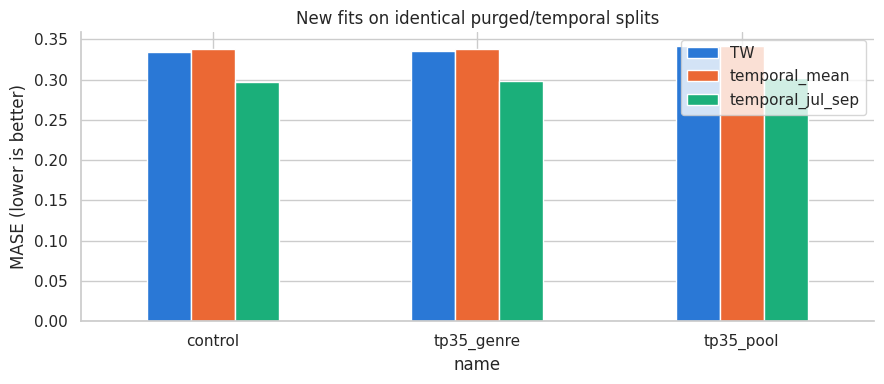

In [31]:
CONTROL_WEIGHTS = {'lgb': 0.1, 'tp35_int7': 0.9}
control_pred, control_temp = blend(CONTROL_WEIGHTS, COMP)
control_lens = lens(control_pred, control_temp)
WEIGHTS = CONTROL_WEIGHTS
ablation_rows, gate_rows, candidate_outputs = [], [], {}
best_tw = control_lens['TW']
for name in ['tp35_genre', 'tp35_pool']:
    weights = {'lgb': 0.1, name: 0.9}
    cp, ct = blend(weights, COMP)
    candidate_outputs[name] = (cp, ct)
    cl = lens(cp, ct)
    delta = {k: cl[k] - control_lens[k] for k in cl}
    units = pd.DataFrame({'unit': WEEK // 2, 'w': TW,
        'wd': (np.abs(y - cp) - np.abs(y - control_pred)) / s * TW}).groupby('unit')[['w', 'wd']].sum()
    ix = np.random.default_rng(CFG.SEED).integers(len(units), size=(4000, len(units)))
    ci = np.quantile(units.wd.values[ix].sum(1) / units.w.values[ix].sum(1), [.0125, .9875])
    error_delta = (np.abs(y - cp) - np.abs(y - control_pred)) / s
    growth = y > Xtr.y3.values
    early = Xtr.h.values <= 5
    gates = dict(TW_gain=delta['TW'] <= -CFG.ABL_MIN_GAIN,
                 official_MASE=delta['MASE'] <= 0,
                 temporal_mean=delta['temporal_mean'] <= 0,
                 temporal_jun_sep=delta['temporal_jun_sep'] <= 0,
                 temporal_jul_sep=delta['temporal_jul_sep'] <= 0,
                 each_month=max(delta[f'temp_{m}'] for m in MONTHS) <= CFG.ABL_MONTH_TOL,
                 fold_wins=sum(delta[f'fold{k}'] < 0 for k in range(CFG.N_FOLDS)) >= CFG.ABL_MIN_FOLDS,
                 block_bootstrap=ci[1] < 0,
                 growth_guard=np.average(error_delta[growth], weights=TW[growth]) <= .003,
                 early_guard=np.average(error_delta[early], weights=TW[early]) <= .003,
                 weights_size=sum(SIZE_MB[n] for n in weights) + CFG.SIZE_MARGIN_MB <= CFG.MAX_WEIGHTS_MB)
    passed = all(gates.values())
    gate_rows.append(dict(candidate=name, **gates, passed=passed, delta_ci_low=ci[0], delta_ci_high=ci[1]))
    ablation_rows.extend([dict(candidate=name, kind='score', **cl), dict(candidate=name, kind='delta', **delta)])
    if passed and cl['TW'] < best_tw:
        WEIGHTS, best_tw = weights, cl['TW']
ablation_rows.append(dict(candidate='control', kind='score', **control_lens))
display(pd.DataFrame(ablation_rows)); display(pd.DataFrame(gate_rows))
pd.DataFrame(ablation_rows).to_csv(CFG.OUTPUT_DIR / 'ablation.csv', index=False)
pd.DataFrame(gate_rows).to_csv(CFG.OUTPUT_DIR / 'adoption.csv', index=False)
print('chosen weights:', WEIGHTS)
oof_final, tp_final = blend(WEIGHTS, COMP)
FEATURE_CFG = 'v17 purged contiguous blocks; fixed candidate recipes'
base_l = lens(*COMP['lgb'])
results.append(score(oof_final, 'selected fixed blend'))
fig, ax = plt.subplots(figsize=(9, 4))
pd.DataFrame([dict(name='control', **control_lens)] +
    [dict(name=n, **lens(*candidate_outputs[n])) for n in candidate_outputs]).set_index('name')[['TW', 'temporal_mean', 'temporal_jul_sep']].plot.bar(ax=ax, rot=0)
ax.set(title='New fits on identical purged/temporal splits', ylabel='MASE (lower is better)')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'v17_ablation.png'); plt.show()

#### Insights

> Split lebih ketat dapat membuat MASE naik. Itu tidak berarti model lebih buruk di test; angka baru harus dibandingkan antar kandidat pada split yang sama. Semua evaluasi tetap dipengaruhi sejarah riset dataset, bukan holdout baru yang tidak pernah dilihat.

---

# Evaluation <a name="9"></a>

---

Galat out-of-fold model final dibedah per bucket skala, per horizon, per bulan rilis, dan per film. Kontribusi per bucket dihitung dengan porsi uji, dan sensitivitas skor terhadap komposisi film diukur dengan bootstrap per film.

,test_share,train_share,mase,zero_rate,contribution_to_test
scale,,,,,
"(0.0, 5.0]",0.015,0.003,2.555,0.758,0.039
"(5.0, 20.0]",0.114,0.029,0.646,0.761,0.074
"(20.0, 50.0]",0.198,0.101,0.414,0.622,0.082
"(50.0, 100.0]",0.200,0.169,0.325,0.520,0.065
"(100.0, 200.0]",0.195,0.235,0.304,0.333,0.059
"(200.0, 500.0]",0.178,0.276,0.289,0.151,0.051
"(500.0, 1000000000.0]",0.100,0.188,0.243,0.026,0.024


TW-MASE by horizon: {4: 0.417, 5: 0.459, 6: 0.327, 7: 0.324, 8: 0.277, 9: 0.273, 10: 0.263}
TW-MASE by release month: {'2025-04': 0.361, '2025-05': 0.471, '2025-06': 0.303, '2025-07': 0.304, '2025-08': 0.292, '2025-09': 0.284}
top-5 films carry 28.2% of the weighted error: ['LILO & STITCH', 'SAYAP SAYAP PATAH 2: OLIVIA', 'SORE ISTRI DARI MASA DEPAN', 'UNTIL DAWN', 'WEAPONS']
final vs LightGBM film bootstrap 95% CI of TW change: [-0.0222, -0.0045] | films better 74/126


,LightGBM,tp35_int7,tp35_genre,tp35_pool,final,TW share
target zero,0.1420,0.1172,0.1146,0.1239,0.1197,0.4277
target positive,0.5006,0.4962,0.4994,0.5046,0.4948,0.5723
growth (y > D3),1.0695,1.0766,1.0868,1.0899,1.0746,0.1693
"positive, no growth",0.2615,0.2522,0.2525,0.2586,0.2512,0.4029
D4-D5,0.4556,0.4379,0.4381,0.4559,0.4381,0.2861


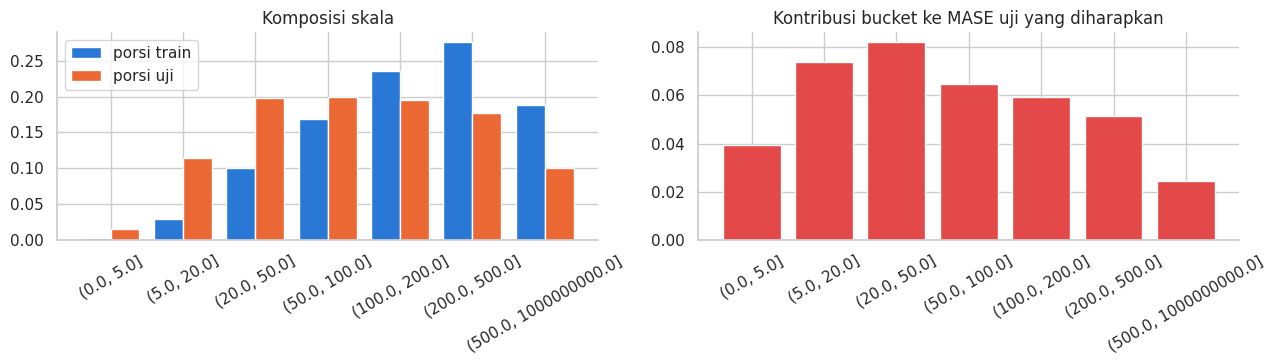

In [32]:
E = Xtr[['movie_title', 'h', 'scale', 'total_ticket', 'd1']].assign(pred=oof_final, w=TW)
E['ae'] = np.abs(E.total_ticket - E.pred) / E.scale
cut = pd.cut(E.scale, CFG.TW_BINS)
bk = pd.DataFrame({'test_share': pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True), 'train_share': cut.value_counts(normalize=True),
                   'mase': E.groupby(cut, observed=False).ae.mean(), 'zero_rate': (E.total_ticket == 0).groupby(cut, observed=False).mean()}).sort_index()
bk['contribution_to_test'] = bk.test_share * bk.mase
display(bk.round(3))
wm = lambda g: np.average(g.ae, weights=g.w)
print('TW-MASE by horizon:', E.groupby('h').apply(wm, include_groups=False).round(3).to_dict())
print('TW-MASE by release month:', E.groupby(E.d1.dt.strftime('%Y-%m')).apply(wm, include_groups=False).round(3).to_dict())
fe = E.assign(c=E.ae * E.w / E.w.sum()).groupby(base_title(E.movie_title)).c.sum()
print(f'top-5 films carry {fe.nlargest(5).sum() / fe.sum():.1%} of the weighted error:', fe.nlargest(5).index.tolist())
d_ = (np.abs(y - oof_final) - np.abs(y - SEL['comp'][0])) / s * TW
G_ = pd.DataFrame({'g': groups, 'd': d_, 'w': TW}).groupby('g').sum()
ix_ = np.random.default_rng(CFG.SEED).integers(0, len(G_), (2000, len(G_)))
ci = np.quantile(G_.d.values[ix_].sum(1) / G_.w.values[ix_].sum(1), [0.025, 0.975])
print(f'final vs LightGBM film bootstrap 95% CI of TW change: [{ci[0]:+.4f}, {ci[1]:+.4f}] | films better {int((G_.d < 0).sum())}/{len(G_)}')

SEGS = {'target zero': y == 0, 'target positive': y > 0, 'growth (y > D3)': y > Xtr.y3.values,
        'positive, no growth': (y > 0) & (y <= Xtr.y3.values), 'D4-D5': hh_ <= 5}
PRED = {'LightGBM': SEL['comp'][0], **{n: COMP[n][0] for n in COMP if n != 'lgb'}, 'final': oof_final}
seg_tab = pd.DataFrame({k: {sg: np.average(np.abs(y[m] - p[m]) / s[m], weights=TW[m]) for sg, m in SEGS.items()} for k, p in PRED.items()})
seg_tab['TW share'] = {sg: TW[m].sum() / TW.sum() for sg, m in SEGS.items()}
display(seg_tab.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
xx = np.arange(len(bk))
ax[0].bar(xx - .2, bk.train_share, .4, label='porsi train'); ax[0].bar(xx + .2, bk.test_share, .4, label='porsi uji')
ax[0].set_xticks(xx, [str(i) for i in bk.index], rotation=30); ax[0].legend(); ax[0].set_title('Komposisi skala')
ax[1].bar(xx, bk.contribution_to_test, color=PAL[7]); ax[1].set_xticks(xx, [str(i) for i in bk.index], rotation=30)
ax[1].set_title('Kontribusi bucket ke MASE uji yang diharapkan')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'evaluation.png'); plt.show()

#### Insights

> Pasangan dengan skala di bawah 50 hanya sekitar 13% baris train tetapi 33% baris uji dan menyumbang porsi terbesar MASE uji yang diharapkan. Lima film menyumbang kira-kira seperempat sampai sepertiga galat berbobot (`eda/51`), sehingga perbedaan versi di bawah lebar interval bootstrap per film tidak boleh dibaca sebagai perbaikan pasti.

> Tabel segmen memisahkan galat pada target nol, target positif, dan pertumbuhan setelah D3 (audit v12: v12 membaik pada nol tetapi memburuk pada film yang masih tumbuh). Segmen tumbuh adalah bagian dari segmen positif, bukan kelompok tambahan. Perbaikan yang hanya memindahkan galat dari satu segmen ke segmen lain harus terlihat di sini sebelum dipercaya.

---

# Inference & Submission <a name="10"></a>

---

Model final dilatih pada seluruh sampel (rilis luas dan rilis terbatas) dengan konfigurasi terpilih. Statistik klaster untuk data uji memakai seluruh train (masa lalu film uji). Tidak ada parameter yang disetel pada leaderboard.

## Minggu Lebaran: Analog Top-Down dari Lebaran 2025

Tujuh judul slate Lebaran 2026 dirilis 18 Maret, sehingga D4 sampai D10 mereka adalah Lebaran hari 1 sampai 7 (6,1% baris uji), periode yang tidak memiliki padanan di sampel latih. Namun `train.csv` dimulai 1 April 2025, yaitu Lebaran 2025 hari ke-2, sehingga total tiket per klaster selama minggu Lebaran 2025 teramati. Prediksi top-down: total slate per klaster pada Lebaran hari ke-$k$ = $\rho$ x total klaster pada Lebaran 2025 hari ke-$k$, dibagi ke pasangan menurut pangsa skala D1 sampai D3. Rasio klaster dirata-rata geometrik dengan rasio nasional agar tidak liar pada klaster kecil.

slate: ['DANUR: THE LAST CHAPTER', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'NA WILLA', 'PELANGI DI MARS', 'SENIN HARGA NAIK', 'SUZZANNA: SANTET DOSA DI ATAS DOSA', 'TUNGGU AKU SUKSES NANTI']
normal 2025 day 217072 | 2025 Lebaran week mean 593714 | 2026 slate mean D1-D3 167461
2026 slate: 1003361 seats/day at occupancy 17% | 2025 slate occupancy median 73%


,rho=0.4,rho=0.5,rho=0.7,rho=1.0,occupancy_needed_rho=0.5
D4 (Lebaran day 1),0.83,1.03,1.45,2.07,17.0
D5 (Lebaran day 2),1.10,1.38,1.93,2.76,23.0
D6 (Lebaran day 3),1.34,1.68,2.35,3.35,28.0
D7 (Lebaran day 4),1.51,1.89,2.64,3.77,31.0
D8 (Lebaran day 5),1.49,1.86,2.61,3.72,31.0
D9 (Lebaran day 6),1.58,1.98,2.77,3.96,33.0
D10 (Lebaran day 7),1.48,1.85,2.59,3.71,31.0


analog mean r by Lebaran day: {1: 1.09, 2: 1.45, 3: 1.78, 4: 2.01, 5: 1.98, 6: 2.1, 7: 1.98}


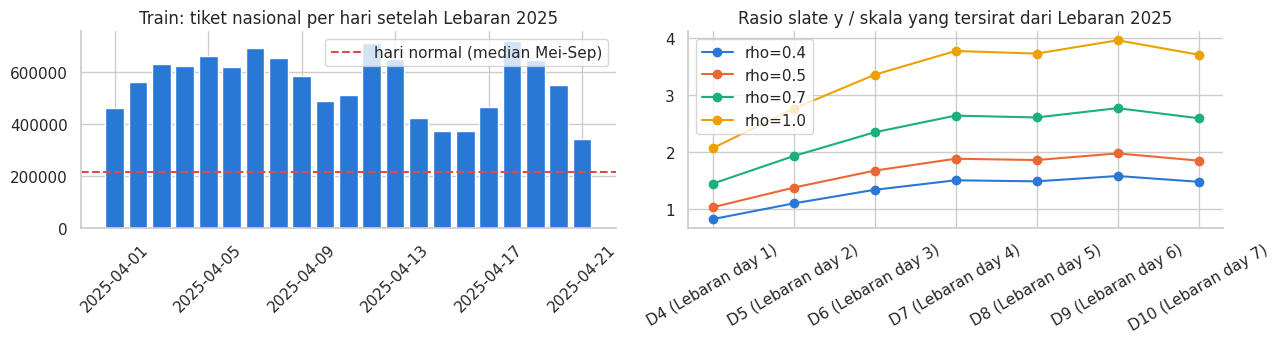

In [33]:
LEB25, LEB26 = pd.Timestamp('2025-03-31'), pd.Timestamp('2026-03-21')
leb_mask = Xte.date_show.between(LEB26, LEB26 + pd.Timedelta(days=6)).values
slate = sorted(Xte.movie_title[leb_mask].unique())
hsl = hist[hist.movie_title.isin(slate)]
day25 = train.groupby('date_show').total_ticket.sum()
normal_day = day25.loc['2025-05-01':].median()
m25 = pd.Series({k: day25[LEB25 + pd.Timedelta(days=k - 1)] for k in range(2, 8)})
m25.loc[1] = CFG.LEB_DAY1 * m25.loc[2]
m25 = m25.sort_index()
S26 = hsl.groupby('date_show').total_ticket.sum().mean()
seats26 = (hsl.total_ticket / (hsl.occupation_rate / 100).clip(lower=.005)).groupby(hsl.date_show).sum().mean()
top25 = train[train.date_show.between('2025-04-01', '2025-04-07')].groupby('movie_title').total_ticket.sum().nlargest(5).index
a25 = train[train.movie_title.isin(top25) & train.date_show.between('2025-04-01', '2025-04-07')]
print('slate:', slate)
print(f'normal 2025 day {normal_day:.0f} | 2025 Lebaran week mean {m25.loc[2:7].mean():.0f} | 2026 slate mean D1-D3 {S26:.0f}')
print(f'2026 slate: {seats26:.0f} seats/day at occupancy {100 * S26 / seats26:.0f}% | 2025 slate occupancy median {a25.occupation_rate.median():.0f}%')
imp_r = pd.DataFrame({f'rho={r_}': r_ * m25 / S26 for r_ in (0.4, 0.5, 0.7, 1.0)})
imp_r.index = [f'D{k + 3} (Lebaran day {k})' for k in imp_r.index]
imp_r['occupancy_needed_rho=0.5'] = (0.5 * m25.values / seats26 * 100).round(0)
display(imp_r.round(2))

c25 = {k: train[train.date_show == LEB25 + pd.Timedelta(days=k - 1)].groupby('cinema_ids').total_ticket.sum() for k in range(2, 8)}
c25[1] = CFG.LEB_DAY1 * c25[2]
c26 = hsl.groupby('cinema_ids').total_ticket.sum() / 3
kday = (Xte.date_show - LEB26).dt.days.values + 1
leb_pred = np.zeros(len(Xte))
for k in range(1, 8):
    m = leb_mask & (kday == k)
    r_nat = m25.loc[k] / S26
    r_cl = (Xte.cinema_ids[m].map(c25[k]) / Xte.cinema_ids[m].map(c26)).values
    r_cl = np.where(np.isfinite(r_cl) & (r_cl > 0), r_cl, r_nat)
    # geometric mean of cluster and national ratio
    leb_pred[m] = Xte.scale.values[m] * CFG.LEB_RHO * np.sqrt(r_cl * r_nat)
print('analog mean r by Lebaran day:', {int(k): round(float((leb_pred / Xte.scale.values)[leb_mask & (kday == k)].mean()), 2) for k in range(1, 8)})

dd = day25.loc['2025-04-01':'2025-04-21']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(dd.index, dd.values, color=PAL[0]); ax[0].axhline(normal_day, color=PAL[7], ls='--', label='hari normal (median Mei-Sep)')
ax[0].set(title='Train: tiket nasional per hari setelah Lebaran 2025'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=45)
imp_r[['rho=0.4', 'rho=0.5', 'rho=0.7', 'rho=1.0']].plot(ax=ax[1], marker='o'); ax[1].tick_params(axis='x', rotation=30)
ax[1].set(title='Rasio slate y / skala yang tersirat dari Lebaran 2025')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'lebaran.png'); plt.show()

#### Insights

> Analog Lebaran dipertahankan persis seperti v15 untuk mengisolasi ablation. Override ini mencakup 6,08% baris test dan belum memiliki validasi lintas Lebaran yang setara. Perubahan 10% pada prediksinya dapat mengubah MASE total paling besar sekitar 0,01076; arah perubahannya tidak diketahui tanpa label. Kapasitas kursi bukan bukti permintaan aktual.

In [34]:
t0 = time.time()
Xall = pd.concat([Xtr, Xlim], ignore_index=True) if CFG.USE_LIMITED else Xtr
XA, XT = with_cin(Xall, STATS_ALL), with_cin(Xte, STATS_ALL)
feats_f, zfeats_f = FEATS, ZFEATS
cm_te, s_te_ = Xte.cal_mult.values, Xte.scale.values
te_comp, final_lgb, lgb_mb = {}, None, 0.0
if WEIGHTS.get('lgb', 0) > 0:
    final_lgb = fit_lgb_all(XA)
    te_comp['lgb'] = lgb_mix(*predict_lgb_all(final_lgb, XT)) * cm_te * s_te_
    lgb_mb = lgb_size_mb(final_lgb)
est_mb = lgb_mb + sum(SIZE_MB[n] for n in WEIGHTS if n != 'lgb')
print(f'weights estimate: LightGBM {lgb_mb:.1f} MB + others {est_mb - lgb_mb:.1f} MB = {est_mb:.1f} MB')
assert est_mb + CFG.SIZE_MARGIN_MB <= CFG.MAX_WEIGHTS_MB, 'weights would exceed the 200 MB rule'
for n in WEIGHTS:
    if n != 'lgb':
        te_comp[n] = quant_median(QFN[n](XA, XT), LAM_CHOICE[n]) * cm_te * s_te_
assert set(te_comp) == set(WEIGHTS), f'component mismatch {set(te_comp)} vs {set(WEIGHTS)}'
pred = np.clip(sum(WEIGHTS[n] * te_comp[n] for n in te_comp), 0, None)
print('model mean r on Lebaran rows:', round(float((pred / s_te_)[leb_mask].mean()), 3), '-> analog', round(float((leb_pred / s_te_)[leb_mask].mean()), 3))
pd.DataFrame({'id': Xte.id, 'model_prediction': pred, 'lebaran_override': leb_mask,
              'final_prediction': np.where(leb_mask, leb_pred, pred)}).to_csv(CFG.OUTPUT_DIR / 'inference_audit.csv', index=False)
pred = np.where(leb_mask, leb_pred, pred)
print(f'final fit + inference: {time.time() - t0:.0f}s')

seg = pd.Series('normal', index=Xte.index)
for n, (a, b) in SEGMENTS.items():
    seg[Xte.date_show.between(a, b)] = n
rr = pred / s_te_
display(pd.DataFrame({'rows': seg.value_counts(), 'mean_r_hat': pd.Series(rr).groupby(seg.values).mean(),
                      'pred_zero_share': pd.Series(rr < .05).groupby(seg.values).mean()}).round(3))
bk_te = pd.cut(Xte.scale, CFG.TW_BINS).astype(str).values
bk_tr = pd.cut(Xtr.scale, CFG.TW_BINS).astype(str).values
display(pd.DataFrame({'test rows': pd.Series(bk_te).value_counts(), 'test mean r_hat / c_mult': pd.Series(rr / cm_te).groupby(bk_te).mean(),
                      'OOF mean r_hat / c_mult': pd.Series(oof_final / s / cm).groupby(bk_tr).mean(),
                      'OOF mean r / c_mult': pd.Series(y / s / cm).groupby(bk_tr).mean()}).round(3))

weights estimate: LightGBM 20.1 MB + others 169.1 MB = 189.3 MB
model mean r on Lebaran rows: 0.716 -> analog 1.769
final fit + inference: 1056s


,rows,mean_r_hat,pred_zero_share
lebaran,4417,1.769,0.000
normal,50551,0.467,0.303
ramadan,12408,0.349,0.494
xmas,5235,0.630,0.073


,test rows,test mean r_hat / c_mult,OOF mean r_hat / c_mult,OOF mean r / c_mult
"(0.0, 5.0]",1120,0.251,0.275,2.600
"(100.0, 200.0]",14147,0.582,0.454,0.530
"(20.0, 50.0]",14392,0.344,0.336,0.524
"(200.0, 500.0]",12901,0.661,0.553,0.607
"(5.0, 20.0]",8288,0.230,0.285,0.612
"(50.0, 100.0]",14504,0.442,0.352,0.468
"(500.0, 1000000000.0]",7259,0.729,0.614,0.629


Submisi disimpan dengan format `id,total_ticket` dan urutan `id` yang sama dengan `sample_submission.csv`. Seluruh bobot (booster LightGBM terkompresi, state TabM beserta transformasi inputnya bila dipakai, dan checkpoint TabPFN terpilih dalam format yang sama persis dengan yang divalidasi) disimpan dalam satu berkas `.pkl`, dengan pemeriksaan batas 200 MB yang menghentikan notebook bila terlampaui.

In [35]:
submission = pd.DataFrame({'id': test.id.values, 'total_ticket': pred})
assert len(submission) == len(sub) and (submission.id.values == sub.id.values).all()
assert submission.total_ticket.notna().all() and (submission.total_ticket >= 0).all()
submission.to_csv(CFG.OUTPUT_DIR / 'submission.csv', index=False)
oof_df = pd.DataFrame({'movie_title': Xtr.movie_title, 'cinema_ids': Xtr.cinema_ids, 'h': Xtr.h, 'fold': FOLD, 'y': y, 'scale': s,
                       'week': WEEK,
                       'oof_lgbmix': oof_lgbmix, 'oof_final': oof_final})
for n in COMP:
    oof_df[f'comp_{n}'] = COMP[n][0]
oof_df['oof_control'] = control_pred
for name, (cp, ct) in candidate_outputs.items():
    oof_df[f'oof_{name}'] = cp
oof_df.to_csv(CFG.OUTPUT_DIR / 'oof.csv', index=False)
temporal_rows = []
for m, (idx, pr) in tp_final.items():
    frame = Xtr.iloc[idx][KEY + ['h', 'date_show', 'scale', 'total_ticket']].copy()
    frame['month'], frame['TW'] = m, TW[idx]
    frame['control'], frame['selected'] = control_temp[m][1], pr
    for name, (_, ct) in candidate_outputs.items():
        frame[name] = ct[m][1]
    temporal_rows.append(frame)
pd.concat(temporal_rows, ignore_index=True).to_csv(CFG.OUTPUT_DIR / 'temporal.csv', index=False)
np.savez_compressed(CFG.OUTPUT_DIR / 'oof_quantiles.npz', lgb_p0=SEL['oof']['p0'], lgb_Q=SEL['oof']['Q'],
                    **{f'{n}_Q': QUANT[n][0] for n in QUANT})
zs = lambda m: zlib.compress(m.booster_.model_to_string().encode(), 9)
fm_used = [n for n in WEIGHTS if n in FM_FILES]
fm_files = {k_: Path(p_).read_bytes() for n in fm_used for k_, p_ in FM_FILES[n].items()}
lgb_blob = None if final_lgb is None else {'l1': [zs(m) for m in final_lgb['l1']], 'zero_clf': zs(final_lgb['zc']),
                                           'quantiles': [zs(m) for m in final_lgb['qm']]}
payload = {'target_transform': {n: 'identity' for n in WEIGHTS},
           'extra_genre_tokens': EXTRA_GENRES, 'extra_genre_features': EXTRA_GENRE_FEATS,
           'variant_features': {n: (list(FEATS) if n in ('lgb', 'tp35_pool') else
               [f for f in FEATS if f != 'h'] + (EXTRA_GENRE_FEATS if n == 'tp35_genre' else [])) for n in WEIGHTS},
           'pool_context': CFG.POOL_CONTEXT, 'pool_sampling_seed': CFG.SEED,
           'lightgbm': lgb_blob,
           'tabm': tabm_blob() if 'tabm' in te_comp else None, 'compression': 'zlib', 'features': feats_f, 'zero_features': zfeats_f,
           'feature_config': FEATURE_CFG, 'pull_a': PULL_A, 'blend_weights': WEIGHTS,
           'pull_shift_per_model': LAM_CHOICE, 'fm_used': fm_used, 'fm_files': fm_files,
           'fm_file_sha256': {k_: sha256(p_) for n in fm_used for k_, p_ in FM_FILES[n].items()},
           'tp35_bits': CFG.TP35_BITS, 'fold_scheme': 'purged contiguous release-week blocks', 'fm_failed': FM_FAIL,
           'settings': {k: v for k, v in vars(Settings).items() if k.isupper()}}
blob = pickle.dumps(payload)
(CFG.OUTPUT_DIR / 'model_weights.pkl').write_bytes(blob)
print(f'weights: {len(blob) / 1e6:.1f} MB (cap {CFG.MAX_WEIGHTS_MB} MB) | foundation model inside: {list(fm_files)} | TabM inside: {payload["tabm"] is not None}')
assert len(blob) / 1e6 <= CFG.MAX_WEIGHTS_MB, 'model weights exceed the 200 MB rule'
display(submission.head())

weights: 189.3 MB (cap 200 MB) | foundation model inside: ['tabpfn-v3.5-full-int7.pack'] | TabM inside: False


,id,total_ticket
0,1,32.654647
1,2,25.047270
2,3,4.599304
3,4,0.000000
4,5,0.013749


#### Insights

> Keputusan, skor per model, manifest split, konteks sampling, OOF, prediksi temporal, dan prediksi sebelum override disimpan. Jika semua kandidat gagal dan submission sama dengan v15/v16, jangan menggunakan slot submission untuk duplikat. Tidak ada bukti skor 0,33662 sampai evaluasi dan submission nyata menunjukkan demikian.